[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhavierc/NLP_taller_1/blob/main/notebook_taller_5_rag.ipynb)

# Taller 5 — Retrieval-Augmented Generation (RAG) sobre casos clínicos SPACCC con Ollama

**Carlos Javier Cepeda, David Salamanca, Jose Milciades Ordoñez**

## Objetivo
En los talleres 1 a 4 usamos el corpus clínico **SPACCC** (Spanish Clinical Case Corpus) para reconocer entidades: síntomas, enfermedades, procedimientos, fármacos y proteínas. En este taller usamos **los mismos 1.000 documentos** con otro objetivo. No entrenamos ningún modelo. Los documentos sirven como **base de conocimiento** de un sistema RAG, y un LLM local servido con [Ollama](https://ollama.com) responde preguntas en lenguaje natural sobre esos casos clínicos y cita los casos de los que sacó la información.

La estructura sigue el notebook de referencia de la Sesión 5 (`1-ollama-rag.ipynb`, RAG sobre Wikihow). Agregamos análisis previos para justificar cada decisión con datos:

| Paso | Contenido |
|---|---|
| 01–02 | Dependencias y configuración |
| 03 | Descarga del corpus (mismas fuentes de Hugging Face que en los talleres anteriores) |
| 04 | **EDA**: estructura, atributos y ejemplos de documentos |
| 05 | **Análisis gráfico** de la distribución de palabras por documento |
| 06 | **Análisis para elegir la estrategia de chunking** |
| 07 | Chunking del corpus con la estrategia elegida |
| 08 | **Comparación de encoders** (tabla teórica + benchmark empírico de recuperación) |
| 09 | Construcción del vector store |
| 10 | `DocumentRetriever` y evaluación de la recuperación |
| 11 | LLM con Ollama |
| 12 | Prompts y `ChatBot` RAG con citas |
| 13 | Preguntas de prueba: RAG frente al LLM sin contexto |
| 14 | Interfaz de chat con Gradio |
| 15 | Conclusiones |

> **Aviso:** es un ejercicio académico. Las respuestas del sistema no constituyen consejo médico.

### Referencias
- Notebook de la Sesión 5: [RAG, Ollama y ChatBots](https://github.com/Ohtar10/icesi-nlp/blob/main/Sesion5/1-ollama-rag.ipynb)
- [Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks](http://arxiv.org/abs/2005.11401)
- [Multilingual E5 Text Embeddings](https://arxiv.org/abs/2402.05672) · [BGE M3-Embedding](https://arxiv.org/abs/2402.03216)
- Corpus: [`IEETA/SPACCC-documents`](https://huggingface.co/datasets/IEETA/SPACCC-documents) y [`IEETA/SPACCC-Spanish-NER`](https://huggingface.co/datasets/IEETA/SPACCC-Spanish-NER)

### PASO 01 — Dependencias

En Colab o Kaggle se instalan las librerías que faltan, sin reemplazar el `torch` con CUDA que ya trae el entorno. En local se asume un entorno con `sentence-transformers`, `transformers`, `torch`, `langchain-text-splitters`, `ollama`, `gradio`, `pandas`, `matplotlib` y `seaborn`. El servidor de Ollama se instala más adelante, en el PASO 11.

**Para correrlo en Kaggle:** en *Settings* del notebook activa **Accelerator → GPU** (T4 basta) e **Internet → On**. Sin GPU, el PASO 02 se detiene. Las salidas que ves ahora son de una corrida local en CPU; al ejecutar el notebook en Kaggle se recalculan el benchmark, el vector store y las respuestas.

In [1]:
# PASO 01 — Dependencias
import os, sys, subprocess, warnings

warnings.filterwarnings('ignore')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
IN_KAGGLE = bool(os.environ.get('KAGGLE_KERNEL_RUN_TYPE'))

if IN_COLAB or IN_KAGGLE:
    # only-if-needed: no sustituir el torch con CUDA del entorno por una rueda de CPU.
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade-strategy', 'only-if-needed',
                    'sentence-transformers', 'langchain-text-splitters', 'ollama', 'gradio'], check=True)
print(f'Colab: {IN_COLAB} | Kaggle: {IN_KAGGLE} | Python {sys.version.split()[0]}')

Colab: True | Kaggle: True | Python 3.13.15


### PASO 02 — Configuración

Todos los parámetros del taller están en `CFG`. Los valores de chunking y el encoder **no se fijaron a priori**: los justifica el análisis de los pasos 06 y 08.

Esta configuración es para **Kaggle con GPU**:

- `device=None` usa CUDA si hay GPU.
- `encoder=None` deja que el benchmark del PASO 08 elija el encoder. Con los resultados ya medidos, esa regla selecciona `multilingual-e5-large`.
- `llm_model='qwen2.5:7b'` cabe en una T4 de 16 GB junto con el encoder y usa la GPU de Ollama. Si la sesión se queda sin memoria de video, cámbialo a `qwen2.5:3b`.

In [2]:
# PASO 02 — Configuración, semillas y dispositivo
import re, json, time, math, random, gc, textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import requests
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

CFG = dict(
    seed=42,
    data_dir=Path('data_taller5'),
    # Tokenizador para el análisis de chunking (XLM-R, compartido por la familia E5 y BGE-M3)
    analysis_tokenizer='intfloat/multilingual-e5-base',
    # Estrategia de chunking (justificada en el PASO 06)
    chunk_size_tokens=256,
    chunk_overlap_tokens=48,
    chunk_header_words=25,
    # Encoders a comparar en el PASO 08
    encoder_candidates=[
        'intfloat/multilingual-e5-small',
        'intfloat/multilingual-e5-base',
        'intfloat/multilingual-e5-large',
        'BAAI/bge-m3',
        'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
    ],
    run_encoder_benchmark=True,
    benchmark_docs=200,
    # None = el benchmark elige (en GPU, multilingual-e5-large). Un nombre fijo omite esa regla.
    encoder=None,
    top_k=5,
    # En una T4 (16 GB) caben e5-large (~2 GB) y este modelo (~5 GB). Alternativa si falta VRAM: 'qwen2.5:3b'.
    llm_model='qwen2.5:7b',
    llm_temperature=0.1,
    llm_num_ctx=4096,
    launch_gradio=True,
    # None = automático (cuda > mps > cpu).
    device=None,
)

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
CFG['data_dir'].mkdir(parents=True, exist_ok=True)

if CFG['device'] is not None:
    DEVICE = CFG['device']
elif torch.cuda.is_available():
    DEVICE = 'cuda'
elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

if IN_KAGGLE and DEVICE != 'cuda':
    raise RuntimeError('Kaggle está sin GPU. En Settings activa Accelerator → GPU y reinicia la sesión.')

CFG['encode_batch_size'] = 64 if DEVICE == 'cuda' else 16

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
gpu = f' | {torch.cuda.get_device_name(0)}' if DEVICE == 'cuda' else ''
print('Dispositivo:', DEVICE, gpu, '| torch', torch.__version__, '| lote de embeddings', CFG['encode_batch_size'])

Dispositivo: cuda  | Tesla T4 | torch 2.11.0+cu128 | lote de embeddings 64


### PASO 03 — Descarga del corpus

Usamos las mismas fuentes que en los talleres 1 a 4:

- `IEETA/SPACCC-documents`: el **texto completo** de cada caso clínico. Es la base de conocimiento del RAG.
- `IEETA/SPACCC-Spanish-NER`: anotaciones de entidades (train/test). En el RAG no se usan para generar respuestas. Las usamos para tres cosas: (1) enriquecer el EDA, (2) guardar como metadato la partición de cada documento y (3) construir preguntas sintéticas para evaluar la recuperación sin etiquetado manual.

Los archivos parquet se guardan en caché en `data_taller5/`.

In [3]:
# PASO 03 — Descarga con caché (mismo procedimiento que en los talleres anteriores)
def download_parquet(repo: str, split: str, name: str) -> pd.DataFrame:
    """Descarga `split` del dataset `repo` de Hugging Face y lo guarda en caché como `name`."""
    path = CFG['data_dir'] / name
    if not path.exists():
        url = f'https://huggingface.co/datasets/{repo}/resolve/main/data/{split}-00000-of-00001.parquet'
        print('Descargando:', name, flush=True)
        error = None
        for attempt in range(3):
            try:
                response = requests.get(url, timeout=(15, 120))
                response.raise_for_status()
                tmp = path.with_suffix('.tmp')
                tmp.write_bytes(response.content)
                pd.read_parquet(tmp)  # No guardar una respuesta inválida como caché.
                tmp.replace(path)
                break
            except Exception as exc:
                error = exc
                print(f'Intento {attempt + 1}/3: {type(exc).__name__}: {exc}', flush=True)
        if not path.exists():
            raise RuntimeError(f'No se pudo descargar {repo}/{split}.') from error
    return pd.read_parquet(path)


def document_id(filename) -> str:
    return Path(str(filename)).stem.removeprefix('es-')


df_docs = download_parquet('IEETA/SPACCC-documents', 'train', 'documents.parquet')
df_ner_train = download_parquet('IEETA/SPACCC-Spanish-NER', 'train', 'annotations_train.parquet')
df_ner_test = download_parquet('IEETA/SPACCC-Spanish-NER', 'test', 'annotations_test.parquet')

df_docs['doc_id'] = df_docs.filename.map(document_id)
df_ner = pd.concat([df_ner_train.assign(split='train'), df_ner_test.assign(split='test')], ignore_index=True)
df_ner['doc_id'] = df_ner.filename.map(document_id)

print('Documentos:', df_docs.shape, '| Anotaciones NER:', df_ner.shape)

Descargando: documents.parquet
Descargando: annotations_train.parquet
Descargando: annotations_test.parquet
Documentos: (1000, 3) | Anotaciones NER: (44996, 8)


## PASO 04 — Análisis exploratorio (EDA) de los documentos

### 4.1 Estructura y atributos del dataset

Revisamos las columnas originales, sus tipos, valores nulos, cardinalidad y duplicados antes de derivar cualquier atributo.

In [4]:
# 4.1 Estructura del dataset original
def schema_table(frame: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        'columna': frame.columns,
        'tipo': [str(t) for t in frame.dtypes],
        'nulos': frame.isnull().sum().values,
        'valores_unicos': frame.nunique().values,
        'ejemplo': [str(frame[c].iloc[0])[:90] + ('…' if len(str(frame[c].iloc[0])) > 90 else '')
                    for c in frame.columns],
    })

display(Markdown(f'**`IEETA/SPACCC-documents`** — {df_docs.shape[0]:,} filas × {df_docs.shape[1] - 1} columnas originales'))
display(schema_table(df_docs[['filename', 'document']]))
display(Markdown(f'**`IEETA/SPACCC-Spanish-NER`** (train + test) — {df_ner.shape[0]:,} anotaciones'))
display(schema_table(df_ner[['filename', 'label', 'start_span', 'end_span', 'text', 'split']]))

checks = {
    'Documentos con texto vacío': int((df_docs.document.str.strip() == '').sum()),
    'Textos duplicados': int(df_docs.document.duplicated().sum()),
    'Identificadores duplicados': int(df_docs.doc_id.duplicated().sum()),
    'Documentos con anotaciones NER': int(df_docs.doc_id.isin(df_ner.doc_id).sum()),
}
display(pd.Series(checks, name='valor').to_frame())

**`IEETA/SPACCC-documents`** — 1,000 filas × 2 columnas originales

,columna,tipo,nulos,valores_unicos,ejemplo
0,filename,object,0,1000,es-S0210-48062009000600012-1.txt
1,document,object,0,1000,"Se trata de un paciente de 56 años, que como antecedentes personales de interés había pres…"


**`IEETA/SPACCC-Spanish-NER`** (train + test) — 44,996 anotaciones

,columna,tipo,nulos,valores_unicos,ejemplo
0,filename,object,0,1000,S0004-06142005000500011-1
1,label,object,0,5,DISEASE
2,start_span,int64,0,4630,50
3,end_span,int64,0,4631,73
4,text,object,0,23878,alergias medicamentosas
5,split,object,0,2,train


,valor
Documentos con texto vacío,0
Textos duplicados,0
Identificadores duplicados,0
Documentos con anotaciones NER,1000


**Interpretación.** El dataset de documentos es muy simple: solo tiene **dos columnas**, `filename` (el identificador del caso, p. ej. `es-S0210-48062009000600012-1.txt`) y `document` (el texto libre del caso clínico). No hay nulos, textos duplicados ni identificadores repetidos, y los 1.000 documentos tienen anotaciones NER (750 de train y 250 de test).

Esto marca una diferencia importante con el notebook de referencia: el dataset de Wikihow trae `title`, `summary` y `url`, que se usaban para enriquecer los chunks y citar fuentes. **SPACCC no trae título, resumen ni URL**, así que derivamos esos metadatos:

- `doc_id`: el nombre del archivo sin prefijo ni extensión. Es un identificador PII de **SciELO** (`S0210-48062009000600012`) más el número del caso dentro del artículo (`-1`).
- `fuente`: la URL del artículo original en SciELO España, construida a partir del PII. Cumple el papel de la `url` de Wikihow en las citas.
- `split`, `n_entidades` y conteos por categoría, a partir de las anotaciones NER.
- Atributos de longitud y estructura: caracteres, palabras, líneas y oraciones.

In [5]:
# 4.2 Atributos derivados por documento
SENTENCE_RE = re.compile(r'(?<=[.!?])(?<!\b[A-Za-z]\.)\s+(?=[A-ZÁÉÍÓÚÑ¿¡])')
LABELS = ['DISEASE', 'SYMPTOM', 'PROCEDURE', 'CHEMICAL', 'PROTEIN']


def split_sentences(text: str) -> list:
    return [s.strip() for s in SENTENCE_RE.split(text) if s.strip()]


def split_paragraphs(text: str) -> list:
    return [p.strip() for p in re.split(r'\n+', text) if p.strip()]


docs = df_docs[['doc_id', 'filename', 'document']].copy()
docs['pii'] = docs.doc_id.str.rsplit('-', n=1).str[0]
docs['caso'] = docs.doc_id.str.rsplit('-', n=1).str[1].astype(int)
docs['fuente'] = 'https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=' + docs.pii
docs['n_caracteres'] = docs.document.str.len()
docs['n_palabras'] = docs.document.str.split().str.len()
docs['n_parrafos'] = docs.document.map(lambda t: len(split_paragraphs(t)))
docs['n_oraciones'] = docs.document.map(lambda t: len(split_sentences(t)))

entity_counts = df_ner.pivot_table(index='doc_id', columns='label', values='text', aggfunc='count', fill_value=0)
docs = docs.merge(df_ner.groupby('doc_id').split.first().rename('split'), on='doc_id', how='left')
docs = docs.merge(entity_counts[LABELS], on='doc_id', how='left').fillna({l: 0 for l in LABELS})
docs['n_entidades'] = docs[LABELS].sum(axis=1).astype(int)

display(docs.drop(columns=['document']).head())
display(docs[['n_caracteres', 'n_palabras', 'n_parrafos', 'n_oraciones', 'n_entidades']]
        .describe(percentiles=[.05, .25, .5, .75, .95]).T.round(1))
display(docs.split.value_counts().rename_axis('split').reset_index(name='documentos'))

,doc_id,filename,pii,caso,fuente,n_caracteres,n_palabras,n_parrafos,n_oraciones,split,DISEASE,SYMPTOM,PROCEDURE,CHEMICAL,PROTEIN,n_entidades
0,S0210-48062009000600012-1,es-S0210-48062009000600012-1.txt,S0210-48062009000600012,1,https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S0210-48062009000600012,3979,561,6,22,test,29,13,32,7,12,93
1,S0211-57352013000300012-1,es-S0211-57352013000300012-1.txt,S0211-57352013000300012,1,https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S0211-57352013000300012,6526,944,20,53,train,29,44,16,3,2,94
2,S0210-56912008000400007-3,es-S0210-56912008000400007-3.txt,S0210-56912008000400007,3,https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S0210-56912008000400007,907,154,3,9,test,5,3,4,0,0,12
3,S1698-69462006000400002-1,es-S1698-69462006000400002-1.txt,S1698-69462006000400002,1,https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1698-69462006000400002,2895,412,4,13,train,8,1,16,3,10,38
4,S0365-66912006001100006-4,es-S0365-66912006001100006-4.txt,S0365-66912006001100006,4,https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S0365-66912006001100006,626,99,1,5,test,3,0,7,0,0,10


,count,mean,std,min,5%,25%,50%,75%,95%,max
n_caracteres,1000.0,2337.0,1104.8,498.0,897.8,1519.8,2156.0,2917.5,4560.1,7466.0
n_palabras,1000.0,350.8,165.1,69.0,140.0,226.0,326.0,438.2,683.1,1172.0
n_parrafos,1000.0,5.2,4.0,1.0,1.0,2.0,4.0,7.0,12.0,38.0
n_oraciones,1000.0,15.3,7.6,2.0,6.0,10.0,14.0,19.0,29.0,65.0
n_entidades,1000.0,45.0,24.1,6.0,15.0,27.0,40.0,57.0,90.0,183.0


,split,documentos
0,train,750
1,test,250


### 4.3 Ejemplos de documentos

Mostramos un documento corto, uno de longitud mediana y las entidades anotadas del ejemplo mediano, para ver qué tipo de información contiene un caso clínico.

In [6]:
# 4.3 Ejemplos: documento corto (percentil 10) y documento mediano
def show_document(row, max_chars=None):
    text = row.document if max_chars is None else row.document[:max_chars] + ' […]'
    header = (f"**{row.doc_id}** · split={row.split} · {row.n_palabras} palabras · "
              f"{row.n_parrafos} párrafos · {row.n_oraciones} oraciones · {row.n_entidades} entidades  \n"
              f"Fuente: {row.fuente}")
    display(Markdown(header))
    print(textwrap.fill(text, width=120, replace_whitespace=False))
    print()

ordered = docs.sort_values('n_palabras').reset_index(drop=True)
example_short = ordered.iloc[int(len(ordered) * 0.10)]
example_median = ordered.iloc[len(ordered) // 2]
show_document(example_short)
show_document(example_median)

**S1138-123X2004000100006-2** · split=test · 165 palabras · 2 párrafos · 6 oraciones · 19 entidades  
Fuente: https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1138-123X2004000100006

Paciente de siete años de edad, en etapa de dentición mixta primera fase, con hábito de succión digital. Presentaba las
siguientes alteraciones: mordida abierta anterior, protrusión dentoalveolar superior, aumento del resalte, mordida
cruzada bilateral posterior, compresión maxilar y rotación del plano oclusal. El patrón de crecimiento tenía tendencia
vertical. En la valoración miofuncional se observó incompetencia labial.

Dado el carácter desfavorable del caso, se
optó por un tratamiento combinado que incluía dispositivos ortodóncicos (quad-helix con reja lingual cementado en los
primeros molares superiores, para producir la expansión del maxilar superior, arco lingual cementado en el maxilar
inferior para impedir la pérdida del espacio de deriva y evitar la extrusión de los molares inferiores y aparatología
extraoral (AEO) de tiro alto para favorecer la intrusión de los molares y permitir de este modo a la mandíbula rotar
hacia delante y hacia arriba cerrando la mordida abierta), ju

**S1139-76322016000300008-1** · split=test · 326 palabras · 6 párrafos · 16 oraciones · 35 entidades  
Fuente: https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1139-76322016000300008

Presentamos el caso de una lactante de cinco meses, que consulta por irritabilidad progresiva de diez días de evolución.
Asocia algún vómito aislado, sin fiebre ni cambios en la orina o las deposiciones. En los últimos días inicia distensión
abdominal y el mismo día de la consulta presenta una expulsión de exudado purulento por el ombligo, motivo por el que
fue derivada desde la consulta de Atención Primaria al Servicio de Urgencias.
Se trataba de una recién nacida a término
con un peso adecuado para la edad gestacional. Cursó un embarazo controlado, sin factores de riesgo infeccioso. El
periodo neonatal transcurrió sin incidencias.
Destaca onfalorrexis a los 14 días de vida, con un pequeño granuloma
residual que precisó cauterización con nitrato de plata en dos ocasiones. No había antecedentes de ombligo húmedo.
A su
llegada a Urgencias, en la exploración física destaca una tumoración roja con expulsión espontánea de pus en el ombligo.
Zona adyacente brillante y distendida, sin eritem

In [7]:
# Entidades anotadas del ejemplo mediano (top 6 por categoría)
ents = df_ner[df_ner.doc_id == example_median.doc_id]
summary_rows = [{'categoría': label, 'n': int((ents.label == label).sum()),
                 'ejemplos': ', '.join(ents[ents.label == label].text.drop_duplicates().head(6))}
                for label in LABELS]
display(pd.DataFrame(summary_rows))

,categoría,n,ejemplos
0,DISEASE,4,"onfalorrexis, granuloma residual, ombligo húmedo, quiste de uraco infectado"
1,SYMPTOM,15,"irritabilidad, vómito, fiebre, cambios en la orina o las deposiciones, distensión abdominal, exudado purulento por e..."
2,PROCEDURE,9,"cauterización con nitrato de plata, exploración física, exploración, hemograma, bioquímica, Se recogió muestra de ex..."
3,CHEMICAL,5,"nitrato de plata, oxígeno, cloxacilina, gentamicina"
4,PROTEIN,2,"proteína C reactiva, PCR"


### 4.4 ¿De qué tratan los casos? Contenido clínico del corpus

Para que el RAG sea útil hay que saber qué preguntas puede responder el corpus. Extraemos con expresiones regulares la edad y el sexo del paciente de la primera oración, que es la que suele presentar al paciente ("Varón de 43 años…"). También listamos las entidades más frecuentes de cada categoría y los encabezados de sección explícitos.

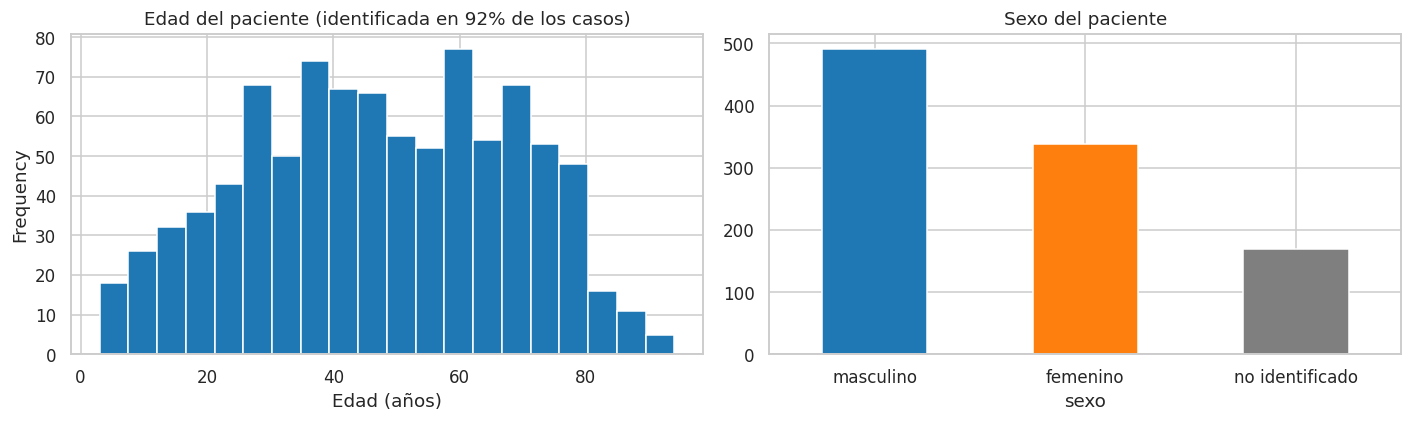

Documentos con algún encabezado de sección explícito ("Exploración física:", ...): 9.4%


,encabezado,apariciones
0,Exploración física,12
1,Diagnóstico,6
2,Antecedentes personales,4
3,Pruebas complementarias,4
4,Analítica,3
5,Enfermedad actual,3
6,Hemograma,3
7,La biometría hemática informó,2
8,Exploraciones complementarias,2
9,Tacto rectal,2


**Entidades más frecuentes por categoría (top 10)**

,DISEASE,SYMPTOM,PROCEDURE,CHEMICAL,PROTEIN
0,lesión,fiebre,exploración física,creatinina,hemoglobina
1,lesiones,dolor,analítica,prednisona,hb
2,hipertensión arterial,asintomático,exploración,corticoides,ldh
3,tumor,vómitos,cirugía,calcio,psa
4,adenopatías,tumoración,tac,urea,pcr
5,fumador,asintomática,intervención,glucosa,albúmina
6,hematoma,astenia,hemograma,bilirrubina,igg
7,metástasis,masa,tc,potasio,igm
8,anemia,dolor abdominal,radiografía de tórax,sodio,ggt
9,neoplasia,proteinuria,ecografía abdominal,oxígeno,gpt


In [8]:
# 4.4 Edad, sexo, encabezados de sección y entidades frecuentes
AGE_RE = re.compile(r'(\d{1,3})\s*años')
MALE_RE = re.compile(r'\b(var[oó]n|hombre|masculino|ni[ñn]o|paciente de sexo masculino)\b', re.I)
FEMALE_RE = re.compile(r'\b(mujer|femenin[oa]|ni[ñn]a|paciente de sexo femenino|gestante|embarazada)\b', re.I)
HEADER_RE = re.compile(r'(?m)^([A-ZÁÉÍÓÚÑ][A-Za-zÁÉÍÓÚÑáéíóúñ ]{2,40}):')


def first_sentences(text, n=2):
    return ' '.join(split_sentences(text)[:n])

docs['edad'] = docs.document.map(lambda t: (m := AGE_RE.search(first_sentences(t))) and int(m.group(1)))
docs['sexo'] = docs.document.map(lambda t: 'masculino' if MALE_RE.search(first_sentences(t))
                                 else 'femenino' if FEMALE_RE.search(first_sentences(t)) else 'no identificado')
headers = docs.document.str.extractall(HEADER_RE)[0].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
docs.edad.dropna().plot.hist(bins=20, ax=axes[0], color='tab:blue', edgecolor='white')
axes[0].set_title(f'Edad del paciente (identificada en {docs.edad.notna().mean():.0%} de los casos)')
axes[0].set_xlabel('Edad (años)')
docs.sexo.value_counts().plot.bar(ax=axes[1], color=['tab:blue', 'tab:orange', 'tab:gray'], rot=0)
axes[1].set_title('Sexo del paciente')
plt.tight_layout(); plt.show()

print(f'Documentos con algún encabezado de sección explícito ("Exploración física:", ...): '
      f'{docs.document.str.contains(HEADER_RE).mean():.1%}')
display(headers.head(10).rename_axis('encabezado').reset_index(name='apariciones'))

top_entities = pd.DataFrame({label: df_ner[df_ner.label == label].text.str.lower().value_counts().head(10).index
                             for label in LABELS})
display(Markdown('**Entidades más frecuentes por categoría (top 10)**'))
display(top_entities)

**Interpretación del EDA.**

- Cada documento es **un caso clínico narrado en prosa continua**, publicado en revistas médicas españolas (SciELO). Casi todos siguen el mismo esquema implícito: presentación del paciente (edad, sexo, antecedentes), enfermedad actual y exploración, pruebas complementarias, diagnóstico, tratamiento y evolución.
- Los **encabezados explícitos son raros**: solo el ~9 % de los documentos tiene alguno ("Exploración física:", "Diagnóstico:"…). No se puede partir el texto por secciones de forma fiable. La estructura visible son **párrafos separados por saltos de línea** y oraciones.
- El texto es muy denso en terminología: unas **45 entidades por documento** de media, con abreviaturas (RTU, PSA, IPSS), valores de laboratorio y unidades. Esto anticipa que el encoder tiene que manejar bien vocabulario médico en español.
- Los casos cubren todas las edades y ambos sexos. Las especialidades son muy variadas (urología, oncología, oftalmología, cirugía torácica…). Las preguntas útiles para el RAG serán del tipo *"¿cómo se trató a un paciente con X?"*, *"¿qué pruebas confirmaron Y?"* o *"¿qué casos describen Z?"*.

## PASO 05 — Análisis gráfico de la distribución de palabras por documento

El notebook de referencia muestra solo un histograma. Aquí miramos la distribución desde varios ángulos: forma (histograma + KDE), comparación train/test, distribución acumulada y relación de la longitud con la densidad de entidades y el número de párrafos.

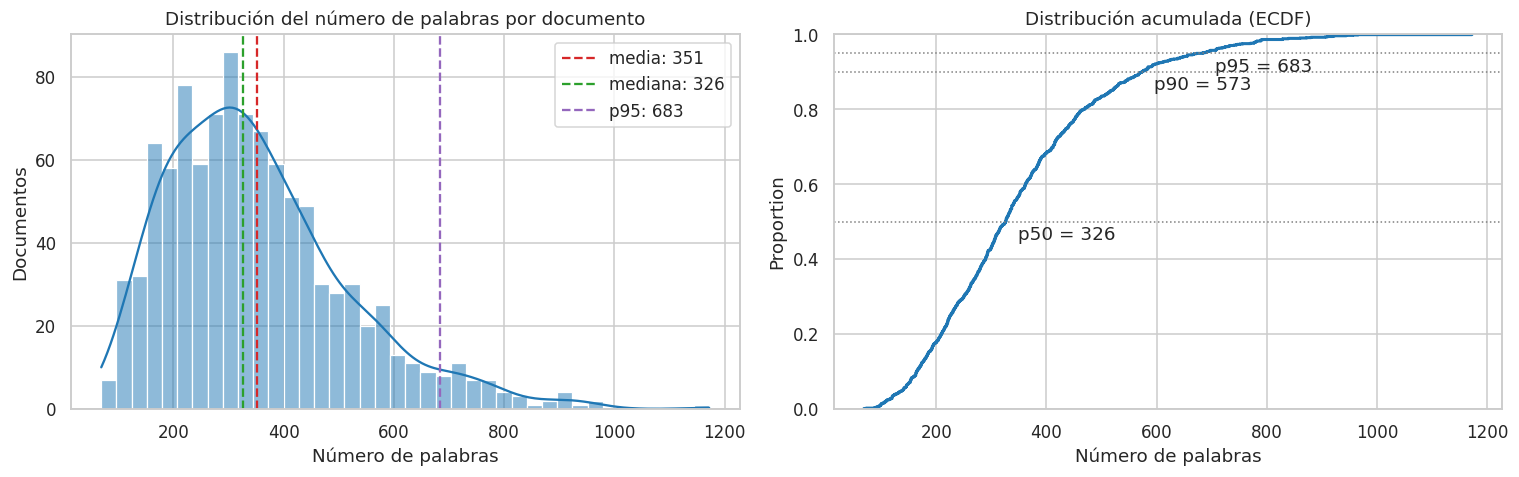

Asimetría: 1.02 | mín: 69 | máx: 1172 | rango intercuartílico: 226–438


In [9]:
# 5.1 Histograma + KDE con estadísticos y distribución acumulada
words = docs.n_palabras
stats = {'media': words.mean(), 'mediana': words.median(), 'p95': words.quantile(.95)}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(words, bins=40, kde=True, ax=axes[0], color='tab:blue')
for (name, value), color in zip(stats.items(), ['tab:red', 'tab:green', 'tab:purple']):
    axes[0].axvline(value, color=color, ls='--', lw=1.5, label=f'{name}: {value:.0f}')
axes[0].set_title('Distribución del número de palabras por documento')
axes[0].set_xlabel('Número de palabras'); axes[0].set_ylabel('Documentos'); axes[0].legend()

sns.ecdfplot(words, ax=axes[1], color='tab:blue', lw=2)
for q in [.5, .9, .95]:
    axes[1].axhline(q, color='gray', ls=':', lw=1)
    axes[1].annotate(f'p{int(q*100)} = {words.quantile(q):.0f}', (words.quantile(q), q),
                     xytext=(8, -12), textcoords='offset points')
axes[1].set_title('Distribución acumulada (ECDF)'); axes[1].set_xlabel('Número de palabras')
plt.tight_layout(); plt.show()

print(f'Asimetría: {words.skew():.2f} | mín: {words.min()} | máx: {words.max()} | '
      f'rango intercuartílico: {words.quantile(.25):.0f}–{words.quantile(.75):.0f}')

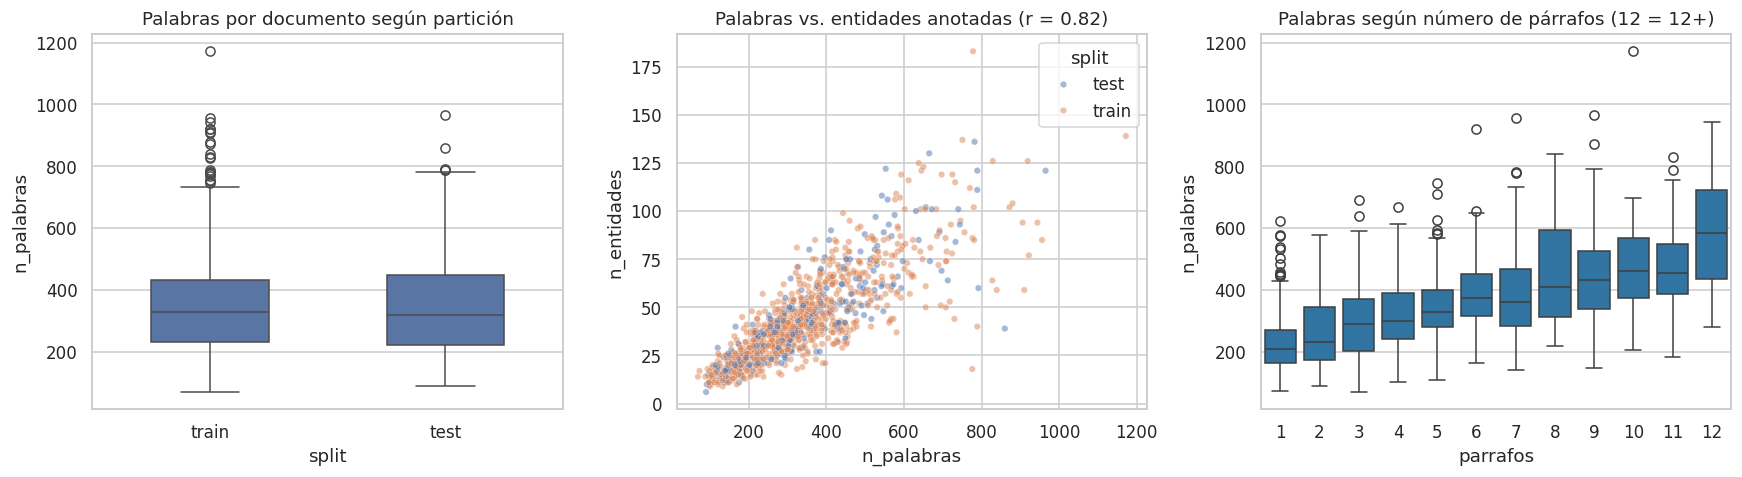

,mediana_n_palabras,mediana_n_entidades,mediana_n_parrafos
split,,,
test,317.5,39.5,4.5
train,328.0,40.5,4.0


In [10]:
# 5.2 Comparación train/test y relación con entidades y párrafos
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=docs, x='split', y='n_palabras', ax=axes[0], order=['train', 'test'], width=.5)
axes[0].set_title('Palabras por documento según partición')

sns.scatterplot(data=docs, x='n_palabras', y='n_entidades', hue='split', alpha=.5, s=18, ax=axes[1])
r = docs[['n_palabras', 'n_entidades']].corr().iloc[0, 1]
axes[1].set_title(f'Palabras vs. entidades anotadas (r = {r:.2f})')

sns.boxplot(data=docs.assign(parrafos=docs.n_parrafos.clip(upper=12)), x='parrafos', y='n_palabras',
            ax=axes[2], color='tab:blue')
axes[2].set_title('Palabras según número de párrafos (12 = 12+)')
plt.tight_layout(); plt.show()

display(docs.groupby('split')[['n_palabras', 'n_entidades', 'n_parrafos']].median().round(1)
        .rename(columns=lambda c: f'mediana_{c}'))

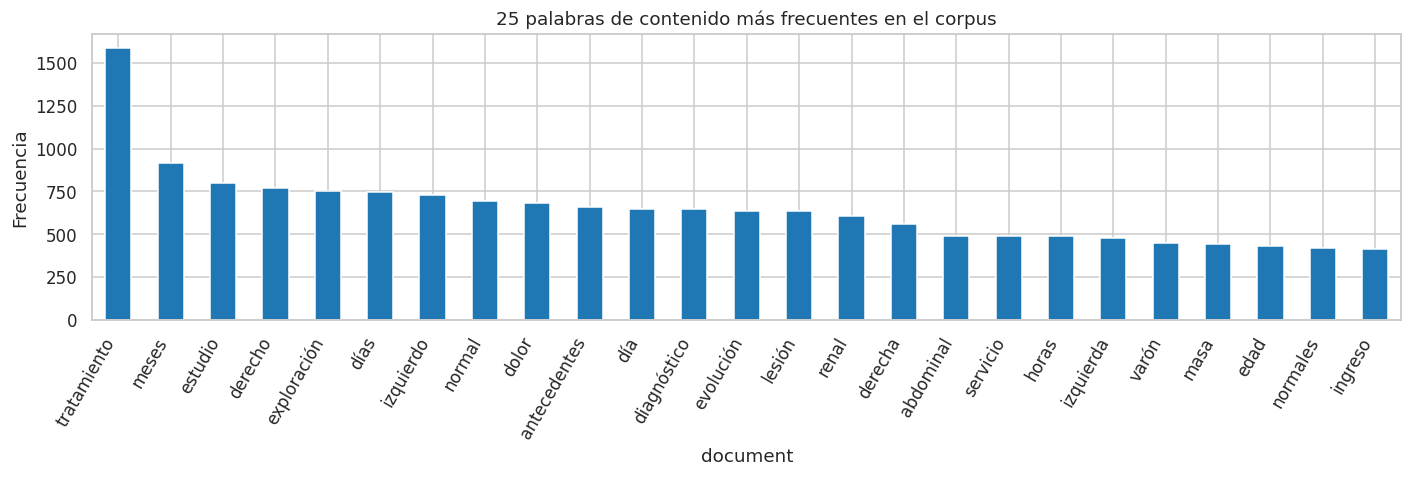

Tamaño del vocabulario (palabras de 3+ letras, en minúsculas): 21,116


In [11]:
# 5.3 Vocabulario de contenido más frecuente (sin palabras vacías)
STOPWORDS_ES = set("""
de la que el en y a los se del las un por con no una su para es al lo como más o pero sus le ha me si sin sobre
este ya entre cuando todo esta ser son dos también fue había era muy años hasta desde está mi porque qué sólo
han yo hay vez puede todos así nos ni parte tiene él uno donde bien tiempo mismo ese ahora cada e vida otro
después te otros aunque esa eso hace otra gran tras se presenta presentaba realizó realiza mediante dicha dicho
cual sido tanto sea durante paciente caso fueron estos estas les tenía nivel unos unas otras ambos ante bajo
""".split())

tokens = (docs.document.str.lower().str.findall(r'[a-záéíóúñü]{3,}').explode())
top_words = tokens[~tokens.isin(STOPWORDS_ES)].value_counts().head(25)

fig, ax = plt.subplots(figsize=(13, 4.5))
top_words.plot.bar(ax=ax, color='tab:blue')
ax.set_title('25 palabras de contenido más frecuentes en el corpus'); ax.set_ylabel('Frecuencia')
plt.xticks(rotation=60, ha='right'); plt.tight_layout(); plt.show()
print(f'Tamaño del vocabulario (palabras de 3+ letras, en minúsculas): {tokens.nunique():,}')

**Interpretación.**

- La distribución tiene **asimetría positiva**: la mayoría de los casos están entre ~230 y ~440 palabras (rango intercuartílico), con mediana ≈ 326 y media ≈ 351. Hay una cola larga que llega a ~1.170 palabras. El 95 % de los documentos tiene menos de ~690 palabras.
- **Train y test tienen la misma distribución de longitudes**. Para el RAG la partición no importa (indexamos los 1.000 documentos), pero confirma que no hay sesgo entre subconjuntos.
- La longitud está **fuertemente correlacionada con el número de entidades** (r ≈ 0,8). Los documentos largos no tienen relleno: traen más información clínica. Partirlos no debería perder densidad.
- Los documentos más largos tienen más párrafos. Los párrafos son la unidad natural de corte.
- El vocabulario dominante es clínico (*tratamiento, diagnóstico, tumoración, lesión, biopsia…*). Esto refuerza la necesidad de un encoder multilingüe robusto al dominio médico.

- El vocabulario es amplio (~21.000 formas distintas de 3 o más letras en solo 1.000 documentos), señal de la diversidad de especialidades y de terminología poco frecuente.

**Consecuencia para el diseño:** un documento de ~350 palabras supera con frecuencia los 512 tokens de subpalabra (se mide en el paso siguiente). Indexar el documento completo truncaría información en una parte importante del corpus, así que **hay que hacer chunking**, y el tamaño de chunk debe expresarse en **tokens del encoder**, no en palabras.

## PASO 06 — Análisis previo para elegir la estrategia de chunking

El notebook de referencia parte cada documento en bloques fijos de 100 palabras, sin respetar oraciones. Antes de elegir estrategia respondemos con datos cuatro preguntas:

1. ¿Cuántos **tokens** (no palabras) tiene cada documento? ¿Cuántos superan el límite de 512 tokens de los encoders?
2. ¿Cuál es la **unidad estructural natural** del texto (secciones, párrafos, oraciones) y qué tamaño tiene?
3. ¿Cómo se comportan las **estrategias candidatas** en número de chunks, tamaño, truncamiento y oraciones cortadas?
4. ¿Qué **contexto pierde** un chunk aislado del resto del documento?

Para contar tokens usamos el tokenizador de `multilingual-e5-base`. Es un tokenizador SentencePiece de XLM-RoBERTa, **el mismo que usan los tres modelos E5 y BGE-M3** candidatos del PASO 08, así que los conteos aplican a todos ellos.

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

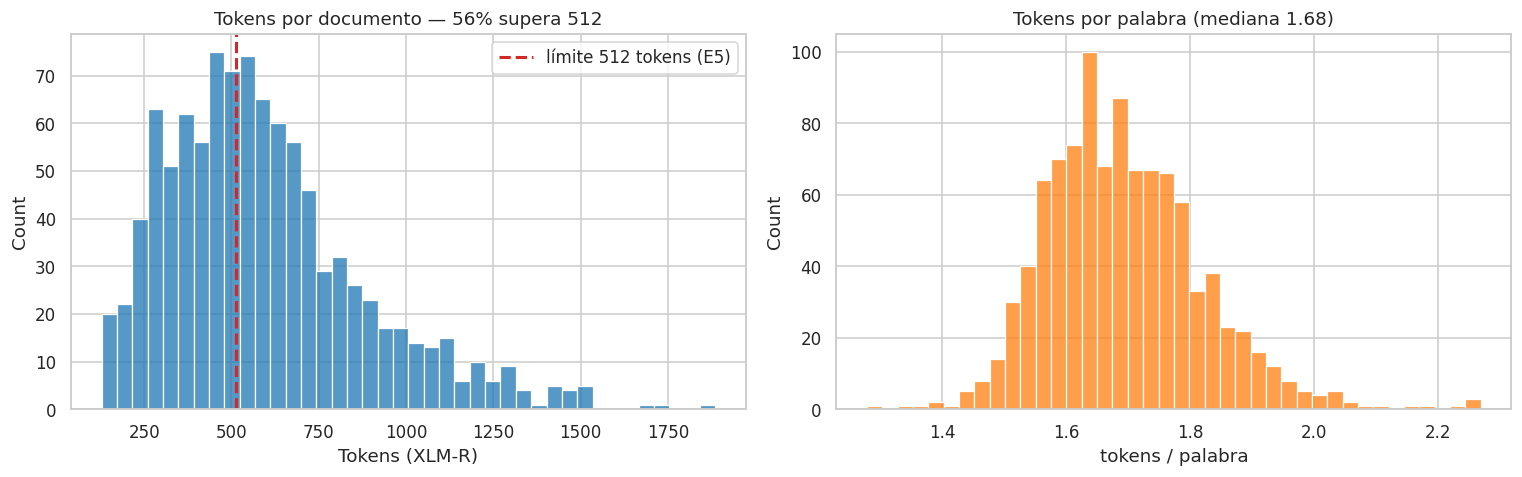

,count,mean,std,min,25%,50%,75%,95%,max
tokens por documento,1000.0,595.0,285.0,128.0,384.0,548.0,736.0,1155.0,1886.0


In [12]:
# 6.1 Tokens por documento y relación tokens/palabra
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CFG['analysis_tokenizer'])
tokenizer.model_max_length = 10**9  # solo contamos tokens; no se pasa nada por el modelo


def n_tokens(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))

docs['n_tokens'] = docs.document.map(n_tokens)
ratio = (docs.n_tokens / docs.n_palabras)
over_512 = (docs.n_tokens > 510).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(docs.n_tokens, bins=40, ax=axes[0], color='tab:blue')
axes[0].axvline(512, color='tab:red', ls='--', lw=2, label='límite 512 tokens (E5)')
axes[0].set_title(f'Tokens por documento — {over_512:.0%} supera 512')
axes[0].set_xlabel('Tokens (XLM-R)'); axes[0].legend()
sns.histplot(ratio, bins=40, ax=axes[1], color='tab:orange')
axes[1].set_title(f'Tokens por palabra (mediana {ratio.median():.2f})'); axes[1].set_xlabel('tokens / palabra')
plt.tight_layout(); plt.show()

display(docs.n_tokens.describe(percentiles=[.25, .5, .75, .95]).round(0).to_frame('tokens por documento').T)

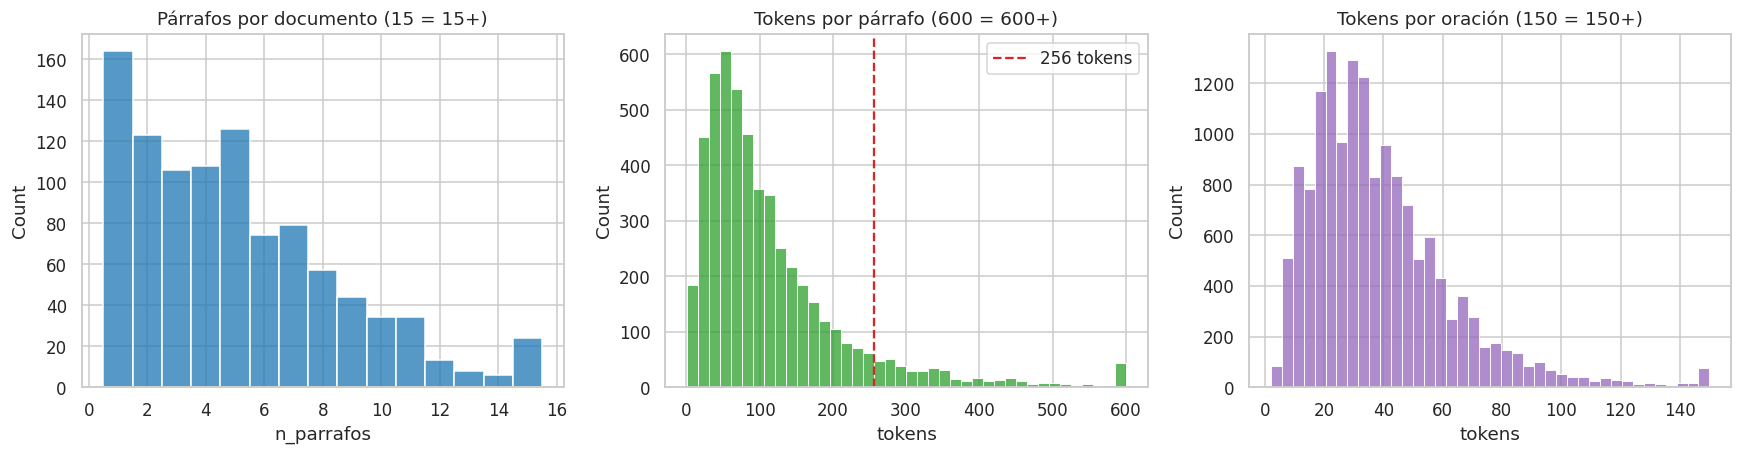

,unidad,cantidad,tokens_mediana,tokens_p95,% > 256 tokens
0,documento,1000,548.5,1155.5,92.0
1,párrafo,5182,83.0,320.8,8.3
2,oración,15294,34.0,84.0,0.1


Documentos de un solo párrafo: 16.4%


In [13]:
# 6.2 Unidades estructurales: párrafos y oraciones
paragraphs = pd.DataFrame([(d, p) for d, t in zip(docs.doc_id, docs.document) for p in split_paragraphs(t)],
                          columns=['doc_id', 'texto'])
paragraphs['tokens'] = paragraphs.texto.map(n_tokens)
sentences = pd.DataFrame([(d, s) for d, t in zip(docs.doc_id, docs.document) for s in split_sentences(t)],
                         columns=['doc_id', 'texto'])
sentences['tokens'] = sentences.texto.map(n_tokens)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
sns.histplot(docs.n_parrafos.clip(upper=15), discrete=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Párrafos por documento (15 = 15+)')
sns.histplot(paragraphs.tokens.clip(upper=600), bins=40, ax=axes[1], color='tab:green')
axes[1].axvline(CFG['chunk_size_tokens'], color='tab:red', ls='--', label=f"{CFG['chunk_size_tokens']} tokens")
axes[1].set_title('Tokens por párrafo (600 = 600+)'); axes[1].legend()
sns.histplot(sentences.tokens.clip(upper=150), bins=40, ax=axes[2], color='tab:purple')
axes[2].set_title('Tokens por oración (150 = 150+)')
plt.tight_layout(); plt.show()

structure = pd.DataFrame({
    'unidad': ['documento', 'párrafo', 'oración'],
    'cantidad': [len(docs), len(paragraphs), len(sentences)],
    'tokens_mediana': [docs.n_tokens.median(), paragraphs.tokens.median(), sentences.tokens.median()],
    'tokens_p95': [docs.n_tokens.quantile(.95), paragraphs.tokens.quantile(.95), sentences.tokens.quantile(.95)],
    f"% > {CFG['chunk_size_tokens']} tokens": [(docs.n_tokens > CFG['chunk_size_tokens']).mean() * 100,
                                         (paragraphs.tokens > CFG['chunk_size_tokens']).mean() * 100,
                                         (sentences.tokens > CFG['chunk_size_tokens']).mean() * 100],
}).round(1)
display(structure)
print(f'Documentos de un solo párrafo: {(docs.n_parrafos == 1).mean():.1%}')

### 6.3 Comparación de estrategias candidatas

Aplicamos a todo el corpus cinco estrategias y medimos:

| Métrica | Por qué importa |
|---|---|
| `n_chunks` | Tamaño del vector store y costo de indexación |
| `tokens_mediana` / `tokens_p95` | Los chunks muy pequeños pierden contexto; los muy grandes diluyen el embedding y ocupan el contexto del LLM |
| `% > 510 tokens` | Fracción que el encoder **truncaría**: información que nunca se indexa |
| `% oraciones cortadas` | Chunks que empiezan o terminan en mitad de una oración. Producen embeddings ruidosos y contexto confuso para el LLM |

Estrategias:

1. **Documento completo**: sin chunking (línea base).
2. **Palabras fijas (100, sin solapamiento)**: la estrategia del notebook de referencia.
3. **Palabras fijas (200, solapamiento 50)**: variante con ventana deslizante.
4. **Oraciones agrupadas**: se acumulan oraciones completas hasta ~256 tokens.
5. **Recursivo por estructura**: `RecursiveCharacterTextSplitter` con longitud medida en tokens del encoder. Intenta cortar primero por párrafo, después por oración (`. `), luego por `;`, `,` y espacio. Se prueba con 128, 256 y 384 tokens y un solapamiento de ~20 %.

In [14]:
# 6.3 Implementación de las estrategias de chunking
from langchain_text_splitters import RecursiveCharacterTextSplitter


def chunk_fixed_words(text: str, size: int, overlap: int = 0) -> list:
    words = text.split()
    step = size - overlap
    return [' '.join(words[i:i + size]) for i in range(0, max(len(words) - overlap, 1), step)]


def chunk_sentences(text: str, max_tokens: int) -> list:
    chunks, buffer, buffer_tokens = [], [], 0
    for sentence in split_sentences(text):
        t = n_tokens(sentence)
        if buffer and buffer_tokens + t > max_tokens:
            chunks.append(' '.join(buffer)); buffer, buffer_tokens = [], 0
        buffer.append(sentence); buffer_tokens += t
    if buffer:
        chunks.append(' '.join(buffer))
    return chunks


def make_recursive_splitter(chunk_size: int, chunk_overlap: int) -> RecursiveCharacterTextSplitter:
    return RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer, chunk_size=chunk_size, chunk_overlap=chunk_overlap,
        separators=['\n\n', '\n', '. ', '; ', ', ', ' ', ''], keep_separator='end', strip_whitespace=True)


STRATEGIES = {
    'documento completo': lambda t: [t],
    'palabras fijas 100 (referencia)': lambda t: chunk_fixed_words(t, 100),
    'palabras fijas 200 / solape 50': lambda t: chunk_fixed_words(t, 200, 50),
    'oraciones agrupadas ≤256 tok': lambda t: chunk_sentences(t, 256),
}
for size in (128, 256, 384):
    splitter = make_recursive_splitter(size, int(size * 0.1875))
    STRATEGIES[f'recursivo {size} tok / solape {int(size * 0.1875)}'] = splitter.split_text

BOUNDARY_END = tuple('.!?:)')


def starts_clean(chunk: str) -> bool:
    return bool(re.match(r'[A-ZÁÉÍÓÚÑ¿¡0-9(«"\-•]', chunk))


def evaluate_strategy(name, fn):
    rows = []
    for doc_id, text in zip(docs.doc_id, docs.document):
        chunks = fn(text)
        for i, ch in enumerate(chunks):
            rows.append({'doc_id': doc_id, 'tokens': n_tokens(ch),
                         'cortada': not (starts_clean(ch) and (ch.rstrip().endswith(BOUNDARY_END) or i == len(chunks) - 1))})
    frame = pd.DataFrame(rows).assign(estrategia=name)
    return frame

t0 = time.perf_counter()
strategy_chunks = pd.concat([evaluate_strategy(n, f) for n, f in STRATEGIES.items()], ignore_index=True)
strategy_table = (strategy_chunks.groupby('estrategia', sort=False)
                  .agg(n_chunks=('tokens', 'size'), chunks_por_doc=('doc_id', lambda s: s.value_counts().mean()),
                       tokens_mediana=('tokens', 'median'), tokens_p95=('tokens', lambda s: s.quantile(.95)),
                       pct_mas_510=('tokens', lambda s: (s > 510).mean() * 100),
                       pct_oraciones_cortadas=('cortada', lambda s: s.mean() * 100))
                  .round(1))
display(strategy_table)
print(f'Tiempo de análisis: {time.perf_counter() - t0:.0f} s')

,n_chunks,chunks_por_doc,tokens_mediana,tokens_p95,pct_mas_510,pct_oraciones_cortadas
estrategia,,,,,,
documento completo,1000,1.0,548.5,1155.5,55.8,0.0
palabras fijas 100 (referencia),4004,4.0,161.5,201.0,0.0,95.3
palabras fijas 200 / solape 50,2494,2.5,317.0,387.0,0.0,87.0
oraciones agrupadas ≤256 tok,2993,3.0,224.0,254.0,0.0,0.0
recursivo 128 tok / solape 24,6938,6.9,94.0,125.0,0.0,3.6
recursivo 256 tok / solape 48,3544,3.5,186.0,251.0,0.0,1.5
recursivo 384 tok / solape 72,2367,2.4,274.0,377.0,0.0,1.2


Tiempo de análisis: 34 s


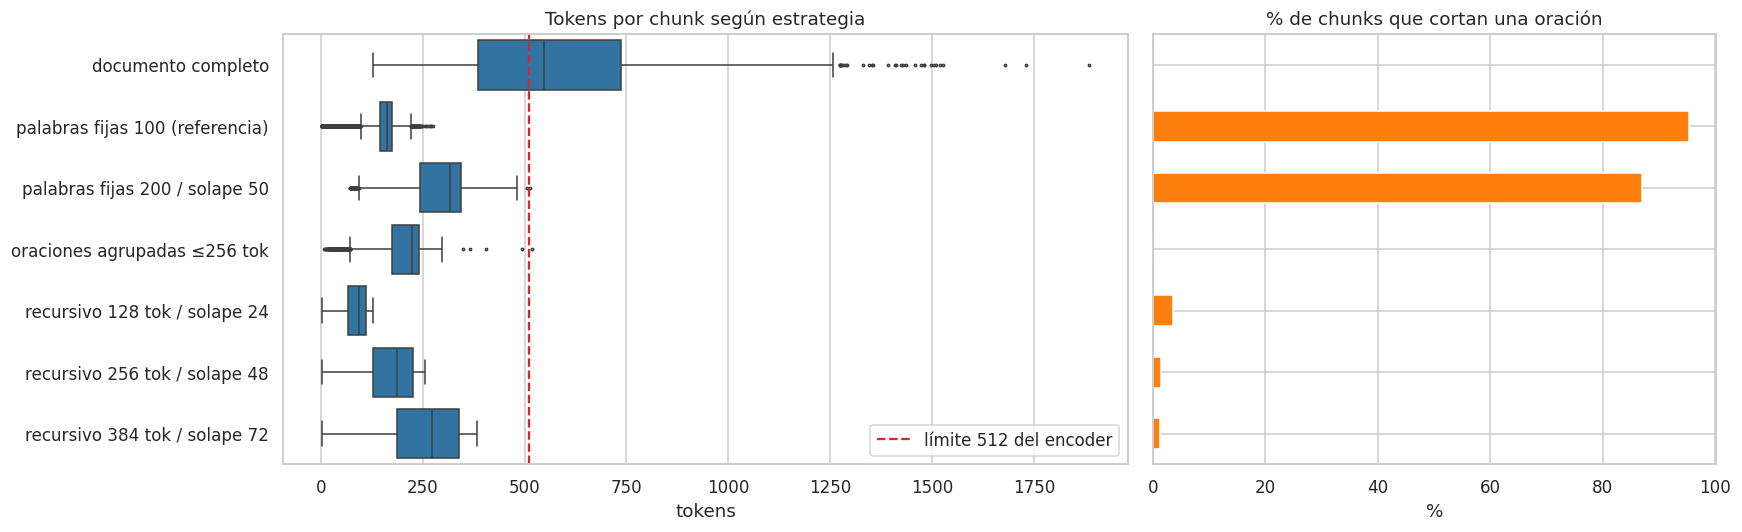

In [15]:
# 6.4 Visualización de las estrategias
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [3, 2]})
order = list(STRATEGIES)
sns.boxplot(data=strategy_chunks, y='estrategia', x='tokens', order=order, ax=axes[0], fliersize=1.5, color='tab:blue')
axes[0].axvline(512, color='tab:red', ls='--', label='límite 512 del encoder')
axes[0].set_title('Tokens por chunk según estrategia'); axes[0].set_ylabel(''); axes[0].legend()
strategy_table.loc[order, 'pct_oraciones_cortadas'].plot.barh(ax=axes[1], color='tab:orange')
axes[1].invert_yaxis(); axes[1].set_yticklabels([]); axes[1].set_ylabel('')
axes[1].set_title('% de chunks que cortan una oración'); axes[1].set_xlabel('%')
plt.tight_layout(); plt.show()

In [16]:
# 6.5 El mismo documento con la estrategia de referencia y con la recursiva
sample_text = example_median.document
for name in ['palabras fijas 100 (referencia)', f"recursivo {CFG['chunk_size_tokens']} tok / solape {int(CFG['chunk_size_tokens'] * 0.1875)}"]:
    display(Markdown(f'**{name}**'))
    for i, ch in enumerate(STRATEGIES[name](sample_text)[:3]):
        print(f'--- chunk {i} ({n_tokens(ch)} tokens) ---')
        print('INICIO: …' + ch[:110].replace('\n', ' '))
        print('FINAL : …' + ch[-110:].replace('\n', ' '))
    print()

**palabras fijas 100 (referencia)**

--- chunk 0 (143 tokens) ---
INICIO: …Presentamos el caso de una lactante de cinco meses, que consulta por irritabilidad progresiva de diez días de 
FINAL : …para la edad gestacional. Cursó un embarazo controlado, sin factores de riesgo infeccioso. El periodo neonatal
--- chunk 1 (168 tokens) ---
INICIO: …transcurrió sin incidencias. Destaca onfalorrexis a los 14 días de vida, con un pequeño granuloma residual que
FINAL : …cuencia cardiaca 139 lpm, presión arterial de 98/51 mmHg y saturación de oxígeno del 100% en aire ambiente. Se
--- chunk 2 (170 tokens) ---
INICIO: …realizó un control analítico con hemograma, donde presentaba leucocitosis con fórmula normal y bioquímica con 
FINAL : …mente se aísla en cultivo de exudado Staphycoccus aureus, manteniendo el tratamiento con cloxacilina con buena



**recursivo 256 tok / solape 48**

--- chunk 0 (197 tokens) ---
INICIO: …Presentamos el caso de una lactante de cinco meses, que consulta por irritabilidad progresiva de diez días de 
FINAL : …dual que precisó cauterización con nitrato de plata en dos ocasiones. No había antecedentes de ombligo húmedo.
--- chunk 1 (160 tokens) ---
INICIO: …Destaca onfalorrexis a los 14 días de vida, con un pequeño granuloma residual que precisó cauterización con ni
FINAL : …frecuencia cardiaca 139 lpm, presión arterial de 98/51 mmHg y saturación de oxígeno del 100% en aire ambiente.
--- chunk 2 (213 tokens) ---
INICIO: …Se realizó un control analítico con hemograma, donde presentaba leucocitosis con fórmula normal y bioquímica c
FINAL : …de la secreción purulenta. Es dada de alta a los seis días de ingreso, con seguimiento por Cirugía Pediátrica.



### 6.6 El problema del contexto perdido

Un caso clínico es una narración: el primer párrafo dice *quién* es el paciente ("Varón de 43 años, previamente sano…") y los siguientes hablan de "el paciente", "la lesión" o "se realizó…". Un chunk del medio del documento, aislado, pierde ese sujeto. Si alguien pregunta *"¿qué tratamiento recibió el varón de 43 años con una tumoración mediastínica?"*, el chunk del tratamiento no menciona ni la edad ni la tumoración.

Una mitigación barata y conocida es la **cabecera contextual** (*contextual chunk header*): al texto que se embebe se le antepone la presentación del caso, es decir, las primeras ~25 palabras del documento. Al LLM se le entrega el chunk junto con su cabecera. En el PASO 08 medimos si esta cabecera mejora la recuperación.

### 6.7 Decisión de chunking

| Criterio | Evidencia | Decisión |
|---|---|---|
| ¿Chunking o documento completo? | Mediana de 548 tokens por documento; el **55,8 %** supera 510 tokens y el encoder truncaría todo lo que pase de ese límite | **Hacer chunking** |
| Unidad de medida | ~1,7 tokens por palabra (595 tokens frente a 351 palabras de media), con mucha variación por abreviaturas y cifras | Medir en **tokens del encoder**, no en palabras |
| Respeto de la estructura | Las palabras fijas cortan oraciones en el **95 %** (100 palabras) y el **87 %** (200/50) de los chunks; el recursivo de 256, solo en el **1,5 %** | **Recursivo**: párrafo → oración → `;` → `,` → espacio |
| Unidad natural | Párrafo: mediana 83 tokens y solo el 8,3 % supera 256; oración: mediana 34 tokens. El 16 % de los documentos es un único párrafo, así que también hace falta cortar por oración | El recursivo cubre ambos casos |
| Tamaño | 128 tokens genera 6.938 chunks de ~94 tokens: una o dos oraciones, sin contexto suficiente. 384 deja 2,4 chunks por documento y mezcla varias fases del caso en un mismo embedding. 256 da 3,5 chunks por documento (≈ 1–3 párrafos, mediana 186 tokens) | **256 tokens** |
| Solapamiento | Hace falta continuidad cuando la información relevante cruza dos chunks, sin inflar el índice | **48 tokens** (~1–2 oraciones, ~19 %) |
| Contexto del caso | Los chunks intermedios pierden al sujeto del caso | **Cabecera contextual** con las primeras 25 palabras (validada en el PASO 08) |

Estos valores son los de `CFG['chunk_size_tokens']`, `CFG['chunk_overlap_tokens']` y `CFG['chunk_header_words']`.

## PASO 07 — Chunking del corpus

Generamos el dataset de chunks con sus metadatos. Este dataset es el equivalente al `documents` del notebook de referencia:

- `chunk_id`, `doc_id`, `chunk_index` y `n_chunks_doc` para trazabilidad.
- `text`: el fragmento que verá el LLM.
- `header`: la presentación del caso (cabecera contextual).
- `embed_text`: lo que se embebe. Es `header + text` en los chunks intermedios; el chunk 0 ya contiene la presentación.
- `split`, `fuente` y `pii` para las citas.

In [17]:
# PASO 07 — Generación de chunks con la estrategia elegida
splitter = make_recursive_splitter(CFG['chunk_size_tokens'], CFG['chunk_overlap_tokens'])


def case_header(text: str, n_words: int) -> str:
    words = text.split()
    return ' '.join(words[:n_words]) + (' …' if len(words) > n_words else '')


rows = []
for doc in docs.itertuples(index=False):
    pieces = splitter.split_text(doc.document)
    header = case_header(doc.document, CFG['chunk_header_words'])
    for i, piece in enumerate(pieces):
        rows.append({
            'chunk_id': f'{doc.doc_id}#{i}', 'doc_id': doc.doc_id, 'chunk_index': i, 'n_chunks_doc': len(pieces),
            'text': piece, 'header': header,
            'embed_text': piece if i == 0 else f'Caso: {header}\n{piece}',
            'n_tokens': n_tokens(piece), 'split': doc.split, 'fuente': doc.fuente,
        })
chunks = pd.DataFrame(rows)

print(f'{len(docs):,} documentos → {len(chunks):,} chunks '
      f'({chunks.groupby("doc_id").size().mean():.2f} chunks por documento)')
display(chunks.n_tokens.describe(percentiles=[.05, .5, .95]).round(0).to_frame('tokens por chunk').T)
display(chunks.iloc[0:len(chunks):max(1, len(chunks) // 8)][['chunk_id', 'chunk_index', 'n_chunks_doc', 'n_tokens', 'text']])

1,000 documentos → 3,544 chunks (3.54 chunks por documento)


,count,mean,std,min,5%,50%,95%,max
tokens por chunk,3544.0,173.0,62.0,4.0,59.0,186.0,251.0,256.0


,chunk_id,chunk_index,n_chunks_doc,n_tokens,text
0,S0210-48062009000600012-1#0,0,6,236,"Se trata de un paciente de 56 años, que como antecedentes personales de interés había presentado una tuberculosis pu..."
443,S0376-78922007000400008-1#3,3,5,184,"En el hemocultivo realizado al ingreso se aísla Estreptococo Pyogenes, por lo que se inicia antibioterapia intraveno..."
886,S0212-71992000001200010-1#0,0,4,158,"Varón de 38 años, con antecedentes de enfermedad de Crohn de 3 años de evolución e ingresado en dos ocasiones por ep..."
1329,S1131-57682003000300008-1#0,0,5,231,Varón de 64 años de edad que acudió a la consulta de AP por tos seca de dos meses de evolución y ocasionalmente sens...
1772,S0210-48062006000200018-1#0,0,2,217,"Paciente de 47 años con antecedentes de ulcus gástrico, fumador de 10 cigarrillos/día, vasectomizado, que consulta p..."
2215,S1139-76322014000400007-1#2,2,4,183,"Durante su estancia en Urgencias, y tras administrar analgesia intravenosa, apareció progresivamente dolor abdominal..."
2658,S1130-05582010000200004-1#0,0,4,231,"Mujer de 70 años de edad, que acudió a su hospital de referencia por tumoración en la cara lateral derecha de la len..."
3101,S0004-06142008000400016-1#1,1,3,133,En la exploración del paciente observamos en el dorso del glande una lesión redondeada exofítica de color rojizo osc...


In [18]:
# Ejemplo: todos los chunks de un documento, con el solapamiento visible
example_chunks = chunks[chunks.doc_id == example_median.doc_id]
for row in example_chunks.itertuples():
    print(f'=== {row.chunk_id} · {row.n_tokens} tokens ===')
    print(textwrap.fill(row.embed_text, width=120, replace_whitespace=False))
    print()

=== S1139-76322016000300008-1#0 · 197 tokens ===
Presentamos el caso de una lactante de cinco meses, que consulta por irritabilidad progresiva de diez días de evolución.
Asocia algún vómito aislado, sin fiebre ni cambios en la orina o las deposiciones. En los últimos días inicia distensión
abdominal y el mismo día de la consulta presenta una expulsión de exudado purulento por el ombligo, motivo por el que
fue derivada desde la consulta de Atención Primaria al Servicio de Urgencias.
Se trataba de una recién nacida a término
con un peso adecuado para la edad gestacional. Cursó un embarazo controlado, sin factores de riesgo infeccioso. El
periodo neonatal transcurrió sin incidencias.
Destaca onfalorrexis a los 14 días de vida, con un pequeño granuloma
residual que precisó cauterización con nitrato de plata en dos ocasiones. No había antecedentes de ombligo húmedo.

=== S1139-76322016000300008-1#1 · 160 tokens ===
Caso: Presentamos el caso de una lactante de cinco meses, que consulta por i

## PASO 08 — Selección del encoder para el vector store

El vector store guarda los embeddings de los chunks. El encoder debe proyectar en un mismo espacio **preguntas cortas** (consultas) y **fragmentos clínicos largos** (pasajes): es una tarea de recuperación **asimétrica**, en **español** y en un **dominio especializado**. Primero comparamos los candidatos en una tabla de características y después medimos su desempeño real con un benchmark sobre nuestro corpus.

### 8.1 Tabla comparativa de encoders

In [19]:
# 8.1 Tabla comparativa de encoders candidatos y descartados
encoders_table = pd.DataFrame([
    dict(modelo='intfloat/multilingual-e5-small', arquitectura='MiniLM (12 capas)', parametros_M=118, dimension=384,
         max_tokens=512, idiomas='~100 (XLM-R)', entrenamiento='Contrastivo débil + supervisado para recuperación',
         prefijos='query: / passage:', en_benchmark='sí',
         comentario='El más liviano de la familia E5; línea base rápida'),
    dict(modelo='intfloat/multilingual-e5-base', arquitectura='XLM-RoBERTa base', parametros_M=278, dimension=768,
         max_tokens=512, idiomas='~100 (XLM-R)', entrenamiento='Contrastivo débil + supervisado para recuperación',
         prefijos='query: / passage:', en_benchmark='sí',
         comentario='Balance calidad/costo; corre bien en CPU'),
    dict(modelo='intfloat/multilingual-e5-large', arquitectura='XLM-RoBERTa large', parametros_M=560, dimension=1024,
         max_tokens=512, idiomas='~100 (XLM-R)', entrenamiento='Contrastivo débil + supervisado para recuperación',
         prefijos='query: / passage:', en_benchmark='sí',
         comentario='El usado en el notebook de referencia; ~2× más lento que base'),
    dict(modelo='BAAI/bge-m3', arquitectura='XLM-RoBERTa large (contexto extendido)', parametros_M=568, dimension=1024,
         max_tokens=8192, idiomas='100+', entrenamiento='Recuperación multi-función (denso, disperso, multi-vector)',
         prefijos='ninguno', en_benchmark='sí',
         comentario='Estado del arte multilingüe abierto; contexto largo (no necesario con chunks de 256)'),
    dict(modelo='sentence-transformers/paraphrase-multilingual-mpnet-base-v2', arquitectura='XLM-RoBERTa base',
         parametros_M=278, dimension=768, max_tokens=128, idiomas='50+',
         entrenamiento='Destilación de paráfrasis (simétrico)', prefijos='ninguno', en_benchmark='sí',
         comentario='Muy popular, pero entrenado para similitud simétrica y trunca a 128 tokens'),
    dict(modelo='sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', arquitectura='MiniLM (12 capas)',
         parametros_M=118, dimension=384, max_tokens=128, idiomas='50+',
         entrenamiento='Destilación de paráfrasis (simétrico)', prefijos='ninguno', en_benchmark='no',
         comentario='Mismas limitaciones que mpnet, con menor capacidad'),
    dict(modelo='hiiamsid/sentence_similarity_spanish_es', arquitectura='BETO (BERT español)', parametros_M=110,
         dimension=768, max_tokens=512, idiomas='español', entrenamiento='STS en español (simétrico)',
         prefijos='ninguno', en_benchmark='no',
         comentario='Monolingüe; entrenado en similitud semántica, no en recuperación'),
    dict(modelo='PlanTL-GOB-ES/roberta-base-biomedical-clinical-es', arquitectura='RoBERTa base', parametros_M=125,
         dimension=768, max_tokens=512, idiomas='español clínico', entrenamiento='Solo MLM (sin objetivo de embeddings)',
         prefijos='—', en_benchmark='no',
         comentario='Dominio ideal pero NO es un encoder de oraciones: requeriría fine-tuning contrastivo'),
    dict(modelo='nomic-embed-text-v2-moe (Ollama)', arquitectura='MoE (305M activos)', parametros_M=475, dimension=768,
         max_tokens=512, idiomas='~100', entrenamiento='Contrastivo para recuperación',
         prefijos='search_query: / search_document:', en_benchmark='no',
         comentario='Alternativa servible desde Ollama; se deja fuera para comparar todo bajo sentence-transformers'),
])
display(encoders_table)

,modelo,arquitectura,parametros_M,dimension,max_tokens,idiomas,entrenamiento,prefijos,en_benchmark,comentario
0,intfloat/multilingual-e5-small,MiniLM (12 capas),118,384,512,~100 (XLM-R),Contrastivo débil + supervisado para recuperación,query: / passage:,sí,El más liviano de la familia E5; línea base rápida
1,intfloat/multilingual-e5-base,XLM-RoBERTa base,278,768,512,~100 (XLM-R),Contrastivo débil + supervisado para recuperación,query: / passage:,sí,Balance calidad/costo; corre bien en CPU
2,intfloat/multilingual-e5-large,XLM-RoBERTa large,560,1024,512,~100 (XLM-R),Contrastivo débil + supervisado para recuperación,query: / passage:,sí,El usado en el notebook de referencia; ~2× más lento que base
3,BAAI/bge-m3,XLM-RoBERTa large (contexto extendido),568,1024,8192,100+,"Recuperación multi-función (denso, disperso, multi-vector)",ninguno,sí,Estado del arte multilingüe abierto; contexto largo (no necesario con chunks de 256)
4,sentence-transformers/paraphrase-multilingual-mpnet-base-v2,XLM-RoBERTa base,278,768,128,50+,Destilación de paráfrasis (simétrico),ninguno,sí,"Muy popular, pero entrenado para similitud simétrica y trunca a 128 tokens"
5,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,MiniLM (12 capas),118,384,128,50+,Destilación de paráfrasis (simétrico),ninguno,no,"Mismas limitaciones que mpnet, con menor capacidad"
6,hiiamsid/sentence_similarity_spanish_es,BETO (BERT español),110,768,512,español,STS en español (simétrico),ninguno,no,"Monolingüe; entrenado en similitud semántica, no en recuperación"
7,PlanTL-GOB-ES/roberta-base-biomedical-clinical-es,RoBERTa base,125,768,512,español clínico,Solo MLM (sin objetivo de embeddings),—,no,Dominio ideal pero NO es un encoder de oraciones: requeriría fine-tuning contrastivo
8,nomic-embed-text-v2-moe (Ollama),MoE (305M activos),475,768,512,~100,Contrastivo para recuperación,search_query: / search_document:,no,Alternativa servible desde Ollama; se deja fuera para comparar todo bajo sentence-transformers


**Lectura de la tabla.** Para nuestro caso descartamos de entrada tres grupos:

- **`paraphrase-multilingual-*`**: fueron entrenados para similitud *simétrica* (frase contra frase) y **truncan a 128 tokens**. Con chunks de ~256 tokens perderían la mitad del contenido. Incluimos `mpnet` en el benchmark solo como contraste, para comprobar empíricamente esa desventaja.
- **Modelos solo en español entrenados para STS** (`sentence_similarity_spanish_es`): tampoco fueron entrenados para recuperación pregunta → pasaje.
- **`roberta-base-biomedical-clinical-es`** es el que mejor conoce el dominio, pero es un modelo de lenguaje enmascarado. Su embedding promedio no está entrenado para similitud. Usarlo exigiría un fine-tuning contrastivo que queda fuera del alcance del taller.

Los candidatos fuertes son la familia **E5 multilingüe** y **BGE-M3**: entrenados específicamente para recuperación asimétrica, con 512 tokens o más (suficiente para nuestros chunks) y tokenizador XLM-R, que cubre bien el español. La tabla no basta para decidir entre ellos, así que lo medimos.

### 8.2 Benchmark empírico de recuperación sobre SPACCC

No existe un conjunto de preguntas y respuestas etiquetado para SPACCC. Construimos **consultas sintéticas a partir de las anotaciones NER**. Para cada documento del benchmark elegimos:

- la enfermedad o síntoma **más específico** del documento (la entidad con menor frecuencia documental en el corpus), y
- el procedimiento, fármaco o proteína más específico,

y los insertamos en plantillas de pregunta del estilo *"¿Qué caso clínico describe a un paciente con {enfermedad} al que se le realizó {procedimiento}?"*. Así las consultas se parecen a las que haría un usuario real: términos clínicos concretos, en forma de pregunta y sin copiar oraciones del texto.

**Protocolo:** se indexan los chunks de `benchmark_docs` = 200 documentos elegidos al azar (semilla 42) y cada consulta debe recuperar algún chunk de **su** documento. Métricas:

- **Recall@1 / Recall@5**: fracción de consultas cuyo documento aparece en el top 1 o top 5.
- **MRR@10**: *mean reciprocal rank* del primer chunk correcto.
- **Chunks/s** y **% truncado**: costo de indexación y fracción de chunks que superan el `max_seq_length` del modelo.

Cada modelo usa sus prefijos oficiales (`query:` / `passage:` en E5). Todos los embeddings se normalizan, así que el producto punto es la similitud coseno.

In [20]:
# 8.2a Consultas sintéticas a partir de las anotaciones NER
from sentence_transformers import SentenceTransformer

ENCODER_PREFIXES = {
    'intfloat/multilingual-e5-small': ('query: ', 'passage: '),
    'intfloat/multilingual-e5-base': ('query: ', 'passage: '),
    'intfloat/multilingual-e5-large': ('query: ', 'passage: '),
}
QUERY_TEMPLATES = [
    '¿Qué caso clínico describe a un paciente con {a} al que se le realizó {b}?',
    '¿Cómo evolucionó el paciente con {a} en el que se usó {b}?',
    'Busco un caso de {a} donde se menciona {b}.',
]

ner_unique = df_ner.assign(term=df_ner.text.str.lower().str.strip()).drop_duplicates(['doc_id', 'term', 'label'])
ner_unique = ner_unique[ner_unique.term.str.len() >= 4]
doc_freq = ner_unique.groupby('term').doc_id.nunique()
ner_unique['df'] = ner_unique.term.map(doc_freq)


def build_query(doc_id: str, idx: int):
    e = ner_unique[ner_unique.doc_id == doc_id].sort_values(['df', 'term'])
    a = e[e.label.isin(['DISEASE', 'SYMPTOM'])]
    b = e[e.label.isin(['PROCEDURE', 'CHEMICAL', 'PROTEIN']) & ~e.term.isin(a.term.head(1))]
    if a.empty or b.empty:
        return None
    return QUERY_TEMPLATES[idx % len(QUERY_TEMPLATES)].format(a=a.term.iloc[0], b=b.term.iloc[0])


rng = np.random.default_rng(CFG['seed'])
bench_doc_ids = sorted(rng.choice(docs.doc_id.values, size=CFG['benchmark_docs'], replace=False))
bench_queries = pd.DataFrame([{'doc_id': d, 'query': build_query(d, i)} for i, d in enumerate(bench_doc_ids)]).dropna()
bench_chunks = chunks[chunks.doc_id.isin(bench_doc_ids)].reset_index(drop=True)
print(f'Benchmark: {len(bench_queries)} consultas · {len(bench_chunks)} chunks de {len(bench_doc_ids)} documentos')
display(bench_queries.head(6))

Benchmark: 199 consultas · 735 chunks de 200 documentos


,doc_id,query
0,S0004-06142006000200013-1,¿Qué caso clínico describe a un paciente con carcinoma ureteral al que se le realizó enucleación de tal lesión?
1,S0004-06142006000600015-1,¿Cómo evolucionó el paciente con cuerpos cavernosos aumentados de consistencia en el que se usó arteriografía pudend...
2,S0004-06142006000700011-1,"Busco un caso de adenocarcinoma moderadamente diferenciado, de alto grado donde se menciona exéresis mediante circun..."
3,S0004-06142006000700013-1,¿Qué caso clínico describe a un paciente con adenocarcinoma moderadamente diferenciado al que se le realizó análogos...
4,S0004-06142006000900008-1,¿Cómo evolucionó el paciente con adenomegalias mesentéricas ni retroperitoneales en el que se usó análisis anatomo-p...
5,S0004-06142006000900013-1,Busco un caso de displasia urotelial donde se menciona biopsia fría.


In [21]:
# 8.2b Funciones de codificación y evaluación
def encode(model, model_name: str, texts, kind: str, batch_size: int = None) -> np.ndarray:
    if batch_size is None:
        batch_size = CFG['encode_batch_size']
    q_prefix, p_prefix = ENCODER_PREFIXES.get(model_name, ('', ''))
    prefix = q_prefix if kind == 'query' else p_prefix
    return model.encode([prefix + t for t in texts], batch_size=batch_size, normalize_embeddings=True,
                        convert_to_numpy=True, show_progress_bar=False).astype(np.float32)


def retrieval_metrics(query_emb, query_doc_ids, passage_emb, passage_doc_ids, k=10) -> dict:
    scores = query_emb @ passage_emb.T
    ranked = np.argsort(-scores, axis=1)[:, :k]
    passage_doc_ids = np.asarray(passage_doc_ids)
    ranks = []
    for row, gold in zip(ranked, query_doc_ids):
        hits = np.where(passage_doc_ids[row] == gold)[0]
        ranks.append(hits[0] + 1 if len(hits) else np.inf)
    ranks = np.array(ranks)
    return {'recall@1': np.mean(ranks <= 1), 'recall@5': np.mean(ranks <= 5), 'recall@10': np.mean(ranks <= 10),
            'mrr@10': np.mean(np.where(np.isfinite(ranks), 1 / ranks, 0))}


def is_oom(exc: Exception) -> bool:
    return 'out of memory' in str(exc).lower()


def free_accelerator_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if DEVICE == 'mps':
        torch.mps.empty_cache()

In [22]:
# 8.2c Ejecución del benchmark (caché por modelo: si se interrumpe, continúa donde quedó)
bench_path = CFG['data_dir'] / f"encoder_benchmark_{CFG['benchmark_docs']}_{CFG['chunk_size_tokens']}.csv"
results = pd.read_csv(bench_path).to_dict('records') if bench_path.exists() else []
done = {r['modelo'] for r in results}
if done:
    print('Modelos ya evaluados (caché):', sorted(done))

if CFG['run_encoder_benchmark']:
    for name in [m for m in CFG['encoder_candidates'] if m not in done]:
        print(f'→ {name}', flush=True)
        device = DEVICE
        while True:
            try:
                t_load = time.perf_counter()
                model = SentenceTransformer(name, device=device)
                load_s = time.perf_counter() - t_load
                t0 = time.perf_counter()
                p_emb = encode(model, name, bench_chunks.embed_text.tolist(), 'passage')
                enc_s = time.perf_counter() - t0
                q_emb = encode(model, name, bench_queries['query'].tolist(), 'query')
                # Ablación: el mismo modelo sin cabecera contextual
                p_emb_nohdr = encode(model, name, bench_chunks.text.tolist(), 'passage')
                break
            except RuntimeError as exc:
                if not is_oom(exc) or device == 'cpu':
                    raise
                print(f'   Sin memoria en {device}; se repite en CPU.', flush=True)
                model = None
                free_accelerator_memory()
                device = 'cpu'
        tok = model.tokenizer
        truncated = np.mean([len(tok.encode(t)) > model.max_seq_length for t in bench_chunks.embed_text])
        metrics = retrieval_metrics(q_emb, bench_queries.doc_id.values, p_emb, bench_chunks.doc_id.values)
        m_nohdr = retrieval_metrics(q_emb, bench_queries.doc_id.values, p_emb_nohdr, bench_chunks.doc_id.values)
        results.append({'modelo': name, 'dispositivo': device, 'dimension': p_emb.shape[1],
                        'max_seq_length': model.max_seq_length,
                        'pct_truncado': truncated * 100, **metrics, 'mrr@10_sin_cabecera': m_nohdr['mrr@10'],
                        'recall@5_sin_cabecera': m_nohdr['recall@5'],
                        'chunks_por_s': len(bench_chunks) / enc_s, 'carga_s': load_s})
        print(f"   R@1={metrics['recall@1']:.3f} R@5={metrics['recall@5']:.3f} MRR={metrics['mrr@10']:.3f} "
              f"| {len(bench_chunks) / enc_s:.1f} chunks/s", flush=True)
        pd.DataFrame(results).to_csv(bench_path, index=False)
        del model, p_emb, p_emb_nohdr, q_emb
        free_accelerator_memory()
elif not results:
    print('Benchmark desactivado (CFG["run_encoder_benchmark"] = False).')

bench_results = pd.DataFrame(results) if results else None
if bench_results is not None:
    display(bench_results.round(3))

→ intfloat/multilingual-e5-small


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (151 > 128). Running this sequence through the model will result in indexing errors


   R@1=0.146 R@5=0.327 MRR=0.222 | 138.1 chunks/s


,modelo,dispositivo,dimension,max_seq_length,pct_truncado,recall@1,recall@5,recall@10,mrr@10,mrr@10_sin_cabecera,recall@5_sin_cabecera,chunks_por_s,carga_s
0,intfloat/multilingual-e5-small,cuda,384,512,0.000,0.528,0.749,0.819,0.616,0.611,0.714,180.906,14.749
1,intfloat/multilingual-e5-base,cuda,768,512,0.000,0.508,0.724,0.804,0.609,0.585,0.724,78.835,8.080
2,intfloat/multilingual-e5-large,cuda,1024,512,0.000,0.548,0.799,0.849,0.649,0.601,0.744,23.369,18.287
3,BAAI/bge-m3,cuda,1024,8192,0.000,0.472,0.668,0.754,0.557,0.557,0.678,22.584,26.524
4,sentence-transformers/paraphrase-multilingual-mpnet-base-v2,cuda,768,128,85.578,0.146,0.327,0.422,0.222,0.274,0.392,138.114,10.764


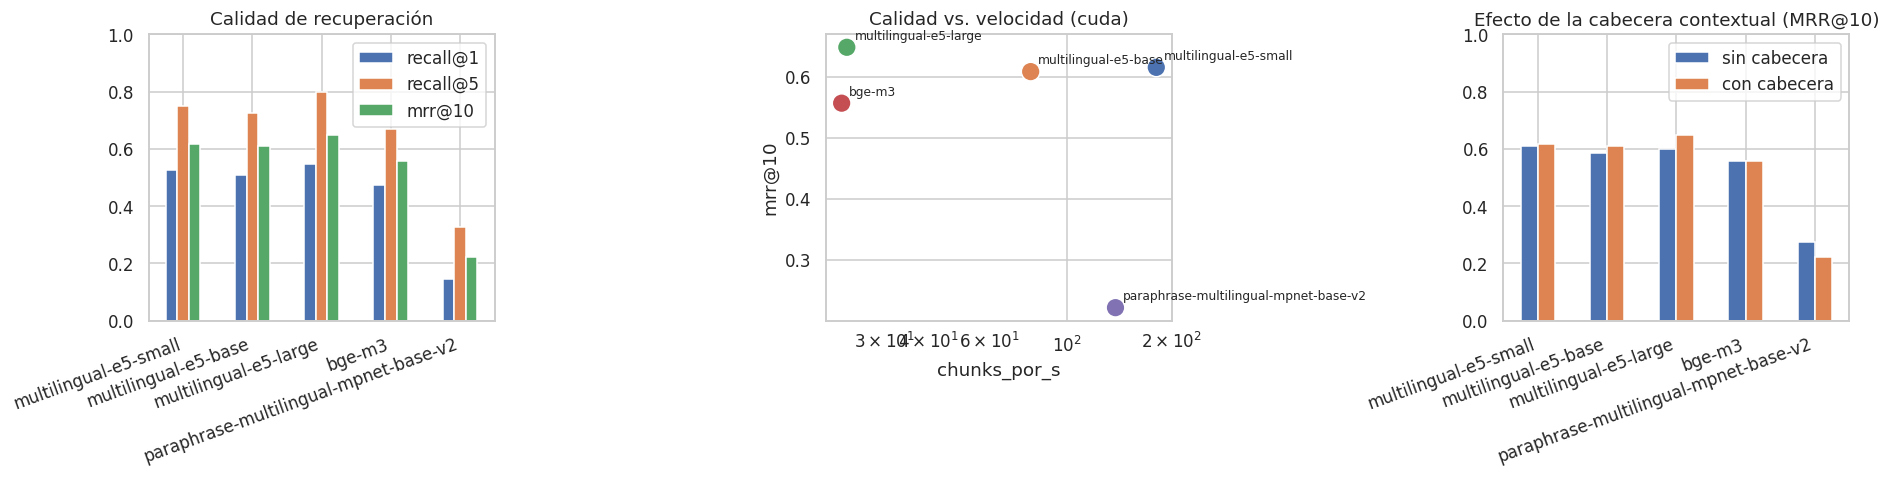

**Encoder seleccionado:** `intfloat/multilingual-e5-large` — el más rápido entre los modelos a ≤ 0,02 de MRR del mejor (0.649).

In [23]:
# 8.3 Visualización del benchmark y selección del encoder
if bench_results is not None:
    short = bench_results.assign(m=bench_results.modelo.str.split('/').str[-1])
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    short.set_index('m')[['recall@1', 'recall@5', 'mrr@10']].plot.bar(ax=axes[0], rot=20)
    axes[0].set_title('Calidad de recuperación'); axes[0].set_ylim(0, 1); axes[0].set_xlabel('')
    for label in axes[0].get_xticklabels():
        label.set_ha('right')
    sns.scatterplot(data=short, x='chunks_por_s', y='mrr@10', hue='m', s=150, ax=axes[1], legend=False)
    for _, row in short.iterrows():
        axes[1].annotate(row['m'], (row['chunks_por_s'], row['mrr@10']), xytext=(5, 5),
                         textcoords='offset points', fontsize=8)
    axes[1].set_title(f'Calidad vs. velocidad ({DEVICE})'); axes[1].set_xscale('log')
    short.set_index('m')[['mrr@10_sin_cabecera', 'mrr@10']].rename(
        columns={'mrr@10_sin_cabecera': 'sin cabecera', 'mrr@10': 'con cabecera'}).plot.bar(ax=axes[2], rot=20)
    axes[2].set_title('Efecto de la cabecera contextual (MRR@10)'); axes[2].set_ylim(0, 1); axes[2].set_xlabel('')
    for label in axes[2].get_xticklabels():
        label.set_ha('right')
    plt.tight_layout(); plt.show()

# Regla de selección: entre los modelos a menos de 0,02 de MRR del mejor, el más rápido.
if CFG['encoder'] is not None:
    ENCODER = CFG['encoder']
    reason = 'fijado manualmente en CFG'
elif bench_results is not None:
    best = bench_results['mrr@10'].max()
    contenders = bench_results[bench_results['mrr@10'] >= best - 0.02]
    ENCODER = contenders.sort_values('chunks_por_s', ascending=False).modelo.iloc[0]
    reason = f'el más rápido entre los modelos a ≤ 0,02 de MRR del mejor ({best:.3f})'
else:
    ENCODER = 'intfloat/multilingual-e5-base'
    reason = 'valor por defecto (sin benchmark)'
display(Markdown(f'**Encoder seleccionado:** `{ENCODER}` — {reason}.'))

**Interpretación del benchmark.** Se midió en CPU (Intel i7-9750H). Las velocidades absolutas cambian mucho con GPU, pero el orden relativo de calidad no.

- **`multilingual-e5-large` es el mejor encoder** para nuestro caso: MRR@10 = 0,649, Recall@1 = 0,548 y Recall@5 = 0,799. Para 4 de cada 5 consultas, el caso correcto aparece entre los 5 primeros resultados.
- **`e5-small` queda segundo** (MRR 0,616, Recall@5 0,749) y es **~7× más rápido** (4,9 frente a 0,68 chunks/s). `e5-base` no supera a `e5-small` (0,609): el salto de calidad aparece recién con el modelo grande.
- **`bge-m3` rinde por debajo de la familia E5** (MRR 0,557), aunque es el más grande y uno de los mejores en benchmarks generales. Una hipótesis plausible, no verificada aquí: nuestras consultas combinan términos clínicos poco frecuentes, y a través de sentence-transformers solo usamos la salida densa de BGE-M3, sin su componente disperso (léxico), que es justamente el que aprovecha ese tipo de coincidencias. Su contexto de 8.192 tokens tampoco aporta nada con chunks de 256.
- **`paraphrase-multilingual-mpnet` se desploma** (MRR 0,222): **trunca el 85,6 % de los chunks** a 128 tokens y fue entrenado para similitud simétrica. Esto confirma empíricamente lo que anticipaba la tabla teórica.
- **La cabecera contextual sí ayuda a los modelos E5**: +0,048 de MRR en `e5-large` (0,601 → 0,649), +0,024 en `e5-base` y +0,035 de Recall@5 en `e5-small`. Es neutra en `bge-m3` y perjudica a `mpnet`, porque la cabecera consume parte de sus 128 tokens. Se mantiene en el diseño.

**Decisión.** La regla automática (el más rápido entre los modelos a ≤ 0,02 del mejor MRR) elige **`e5-large`**: queda 0,033 de MRR por encima de `e5-small`, fuera de ese margen. En la corrida local en CPU se había fijado `e5-small` porque indexar los 3.544 chunks con `e5-large` tomaba unos 87 minutos. **La configuración actual es la de Kaggle con GPU** (`encoder=None`, `device=None`): al ejecutar el notebook allí se usa CUDA y queda `e5-large`. En una T4 esa indexación pasa de más de una hora a unos pocos minutos.

## PASO 09 — Construcción del vector store

Codificamos los `embed_text` de **todos** los chunks del corpus con el encoder seleccionado. El notebook de referencia limita el índice a 5.000 chunks; aquí el corpus completo cabe sin problema. El vector store es una matriz `float32` de forma `(n_chunks, dimensión)` con filas normalizadas. Se guarda en disco con una clave que incluye el modelo y la configuración de chunking, para no recalcularla si nada cambia.

Para ~3.500 chunks una búsqueda exhaustiva con NumPy tarda milisegundos, así que no hace falta un índice aproximado (FAISS, HNSW). Ese tipo de índice tendría sentido con cientos de miles de chunks.

In [24]:
# PASO 09 — Vector store con caché en disco
encoder = SentenceTransformer(ENCODER, device=DEVICE)
encoder_device = DEVICE
store_key = f"{ENCODER.replace('/', '__')}_{CFG['chunk_size_tokens']}_{CFG['chunk_overlap_tokens']}_{CFG['chunk_header_words']}"
store_path = CFG['data_dir'] / f'vectorstore_{store_key}.npy'
ids_path = store_path.with_suffix('.ids.json')

if store_path.exists() and json.loads(ids_path.read_text()) == chunks.chunk_id.tolist():
    vectorstore = np.load(store_path)
    print('Vector store cargado de caché:', store_path)
else:
    t0 = time.perf_counter()
    try:
        vectorstore = encode(encoder, ENCODER, chunks.embed_text.tolist(), 'passage')
    except RuntimeError as exc:
        if not is_oom(exc) or DEVICE == 'cpu':
            raise
        print(f'Sin memoria en {DEVICE}; el vector store se calcula en CPU.')
        free_accelerator_memory()
        encoder, encoder_device = encoder.to('cpu'), 'cpu'
        vectorstore = encode(encoder, ENCODER, chunks.embed_text.tolist(), 'passage')
    np.save(store_path, vectorstore)
    ids_path.write_text(json.dumps(chunks.chunk_id.tolist()))
    print(f'Vector store calculado en {time.perf_counter() - t0:.0f} s y guardado en {store_path}')

print('Forma del vector store:', vectorstore.shape, '| normas ≈', np.linalg.norm(vectorstore[:5], axis=1).round(3))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Vector store calculado en 176 s y guardado en data_taller5/vectorstore_intfloat__multilingual-e5-large_256_48_25.npy
Forma del vector store: (3544, 1024) | normas ≈ [1. 1. 1. 1. 1.]


## PASO 10 — `DocumentRetriever`

Igual que en el notebook de referencia, el retriever proyecta la consulta al espacio del encoder, calcula la similitud (producto punto entre vectores normalizados, es decir, coseno) contra todo el vector store y devuelve el **texto** de los top-k chunks, no sus embeddings, porque el LLM tiene su propio tokenizador y espacio de representación. Respecto de la referencia hay tres diferencias:

- se aplica el prefijo de consulta del encoder (`query:` en E5), obligatorio para un rendimiento correcto;
- cada resultado incluye sus metadatos (`doc_id`, `fuente`, cabecera) para citar;
- `max_per_doc` limita cuántos chunks de un mismo caso entran al contexto, para dar algo de diversidad.

In [25]:
# PASO 10 — DocumentRetriever
class DocumentRetriever:

    def __init__(self, chunks: pd.DataFrame, vectorstore: np.ndarray, model: SentenceTransformer, model_name: str) -> None:
        self.chunks = chunks.reset_index(drop=True)
        self.vectorstore = vectorstore
        self.model = model
        self.model_name = model_name

    def search(self, query: str, k: int = 5, max_per_doc: int = 2) -> list:
        q = encode(self.model, self.model_name, [query], 'query')[0]
        scores = self.vectorstore @ q
        results, per_doc = [], Counter()
        for i in np.argsort(-scores):
            row = self.chunks.iloc[i]
            if per_doc[row.doc_id] >= max_per_doc:
                continue
            per_doc[row.doc_id] += 1
            results.append({**row[['chunk_id', 'doc_id', 'text', 'header', 'fuente']].to_dict(),
                            'score': float(scores[i])})
            if len(results) == k:
                break
        return results


retriever = DocumentRetriever(chunks, vectorstore, encoder, ENCODER)


def show_results(results):
    display(pd.DataFrame(results)[['score', 'chunk_id', 'text']].assign(
        text=lambda d: d.text.str.slice(0, 160) + '…').round(3))

Probamos el retriever con una pregunta sobre el documento de ejemplo mediano del PASO 04 y con una pregunta temática general.

In [26]:
probe_question = f'¿Qué le ocurrió al paciente del caso que empieza así: "{case_header(example_median.document, 12)}"?'
print('Consulta:', probe_question)
print('Documento esperado:', example_median.doc_id)
show_results(retriever.search(probe_question, k=CFG['top_k']))

Consulta: ¿Qué le ocurrió al paciente del caso que empieza así: "Presentamos el caso de una lactante de cinco meses, que consulta por …"?
Documento esperado: S1139-76322016000300008-1


,score,chunk_id,text
0,0.886,S1139-76322016000300008-1#0,"Presentamos el caso de una lactante de cinco meses, que consulta por irritabilidad progresiva de diez días de evoluc..."
1,0.881,S1139-76322016000300008-1#1,"Destaca onfalorrexis a los 14 días de vida, con un pequeño granuloma residual que precisó cauterización con nitrato ..."
2,0.873,S1139-76322015000400006-1#0,"Presentamos el caso de un lactante de tres meses de edad con historia de rechazo de tomas, náuseas, regurgitaciones ..."
3,0.869,S1139-76322015000400016-1#0,"Lactante varón de un mes de vida, sin antecedentes personales de interés, que acude por tercera vez a Urgencias en l..."
4,0.869,S1139-76322009000200009-1#2,Se le realizaron radiografías de tórax anteroposterior y lateral en las que se objetivó atrapamiento aéreo con prese...


In [27]:
show_results(retriever.search('¿Qué tratamientos se usan para la tuberculosis?', k=CFG['top_k']))

,score,chunk_id,text
0,0.852,S0210-48062004000900010-1#4,"Informe de AP: cistitis granulomatosa tuberculoide, compatible con TBC.\nLowenstein en orina: Positivo para Mycobact..."
1,0.845,S0210-48062009000600017-1#1,Se diagnostica de tuberculosis genitourinaria por cultivo de Lowestein positivo en la orina evacuada por la nefrosto...
2,0.843,S0465-546X2009000300008-1#3,Imagen 5. Estudio Microbiológico\n\nSe confirma el Diagnóstico de Tuberculosis Cutánea y se derivada a la trabajador...
3,0.843,S0212-71992007001000007-1#4,En la evolución del paciente se observó que a los 5 días de iniciar el tratamiento corticoideo desapareció el edema ...
4,0.842,S1137-66272011000100013-1#2,Una TAC mostró que la lesión cavitada se había reducido de tamaño tras 7 meses de tratamiento con voriconazol. El pa...


### 10.1 Evaluación de la recuperación sobre el índice completo

El benchmark del PASO 08 usaba solo 200 documentos. Ahora repetimos la medición con **todo** el vector store, con unos 1.000 documentos que compiten como distractores y consultas sintéticas para todos los documentos. Así estimamos con qué frecuencia el chatbot verá el caso correcto en su contexto.

In [28]:
# 10.1 Recall@k y MRR sobre los 1.000 documentos
all_queries = pd.DataFrame([{'doc_id': d, 'query': build_query(d, i)} for i, d in enumerate(docs.doc_id)]).dropna()
q_emb_all = encode(encoder, ENCODER, all_queries['query'].tolist(), 'query')
full_metrics = retrieval_metrics(q_emb_all, all_queries.doc_id.values, vectorstore, chunks.doc_id.values)
display(pd.DataFrame([{**full_metrics, 'consultas': len(all_queries), 'chunks_indexados': len(chunks)}]).round(3))

,recall@1,recall@5,recall@10,mrr@10,consultas,chunks_indexados
0,0.426,0.622,0.68,0.506,999,3544


## PASO 11 — Implementación del LLM con Ollama

Mantenemos la abstracción del notebook de referencia: una clase base `LLM` con `completion_stream`/`completion` y una implementación `Ollama`. Agregamos opciones de generación: temperatura baja, porque en un RAG clínico queremos respuestas fieles al contexto y no creativas, y `num_ctx` para que quepan los 5 chunks recuperados más la pregunta.

**Modelo:** `qwen2.5:7b` (~5 GB). En Kaggle, Ollama lo carga en la misma GPU que el encoder. Una T4 de 16 GB alcanza para los dos. Si `ollama pull` o la primera respuesta fallan por memoria, cambia `CFG['llm_model']` a `qwen2.5:3b` y vuelve a ejecutar desde esta sección.

In [29]:
# 11.1 Abstracción LLM (igual que en el notebook de referencia)
from abc import abstractmethod
from typing import Any, Generator
import ollama


class LLM:

    @abstractmethod
    def completion_stream(self, *args: Any, **kwargs: Any) -> Generator:
        raise NotImplementedError

    def completion(self, *args, **kwargs) -> str:
        return ''.join(self.completion_stream(*args, **kwargs))


class Ollama(LLM):

    def __init__(self, model: str, temperature: float = 0.1, num_ctx: int = 4096, num_gpu: int = None) -> None:
        super().__init__()
        self.model = model
        self.options = {'temperature': temperature, 'num_ctx': num_ctx}
        if num_gpu:
            # 99 descarga todas las capas a la GPU. Sin esto Ollama puede quedarse en CPU.
            self.options['num_gpu'] = num_gpu

    def completion_stream(self, messages) -> Generator[str, None, None]:
        stream = ollama.chat(model=self.model, messages=messages, stream=True, options=self.options)
        for chunk in stream:
            content = chunk['message']['content']
            yield content if content is not None else ''

Instalamos Ollama si no está disponible, levantamos el servidor si no responde y descargamos el modelo si no existe localmente.

#### ¡ATENCIÓN!
En Colab, si el servidor no queda corriendo en segundo plano, abre una terminal y ejecuta `ollama serve &`. En Kaggle la celda lo levanta sola; hace falta **Internet** activado para `ollama pull`.

In [30]:
# 11.2 Instalar / levantar Ollama y descargar el modelo
import shutil

if (IN_COLAB or IN_KAGGLE) and shutil.which('ollama') is None:
    subprocess.run('apt-get install -y -qq zstd > /dev/null; curl -fsSL https://ollama.com/install.sh | sh',
                   shell=True, check=True)


def ollama_running() -> bool:
    try:
        ollama.list()
        return True
    except Exception:
        return False


if DEVICE == 'cuda':
    # Suelta la caché de PyTorch para que Ollama pueda reservar VRAM junto al encoder.
    torch.cuda.empty_cache()

if not ollama_running():
    print('Levantando "ollama serve" en segundo plano…')
    subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for _ in range(30):
        time.sleep(1)
        if ollama_running():
            break
assert ollama_running(), 'No se pudo contactar el servidor de Ollama.'

local_models = [getattr(m, 'model', None) or m.get('name') for m in ollama.list()['models']]
if CFG['llm_model'] not in local_models:
    print(f"Descargando {CFG['llm_model']}…")
    ollama.pull(CFG['llm_model'])
print('Modelos disponibles en Ollama:', local_models)

llm_ollama = Ollama(model=CFG['llm_model'], temperature=CFG['llm_temperature'], num_ctx=CFG['llm_num_ctx'],
                    num_gpu=99 if DEVICE == 'cuda' else None)
print(llm_ollama.completion([{'role': 'user', 'content': 'Responde solo "listo" si me entiendes.'}]))

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


Levantando "ollama serve" en segundo plano…
Descargando qwen2.5:7b…
Modelos disponibles en Ollama: []
listo


## PASO 12 — Prompts y `ChatBot` RAG

Igual que en la referencia, el LLM no ve embeddings: recibe un prompt con los fragmentos recuperados **en texto plano**. Adaptamos las plantillas al dominio clínico:

- Cada fragmento va etiquetado con su caso (`[Caso S0210-…-1]`) y su cabecera contextual, para que el modelo sepa a qué paciente pertenece y pueda citarlo.
- Se le pide responder **solo** con la información de los fragmentos y decir explícitamente cuando no está, para reducir alucinaciones.
- La plantilla de historial reformula una pregunta de seguimiento como pregunta autónoma antes de buscar (*query rewriting*).

Además corregimos dos detalles del notebook de referencia: `follow_up_query` enviaba un string donde `ollama.chat` espera una lista de mensajes, y el historial guardaba el prompt completo, con los documentos, en vez de la pregunta del usuario.

In [31]:
# 12.1 Plantillas de prompt
document_separator = '\n\n'

system_template = """Eres un asistente que responde preguntas sobre una colección de casos clínicos publicados en revistas médicas españolas.
Responde en español, de forma clara y concisa, usando EXCLUSIVAMENTE la información de los fragmentos de contexto.
Si la respuesta no está en los fragmentos, responde: "No encuentro esa información en los casos clínicos disponibles."
Cuando uses información de un caso, menciona su identificador entre corchetes, por ejemplo [Caso S0210-48062009000600012-1].
No inventes datos, dosis ni diagnósticos que no aparezcan en el contexto."""

question_template = """Fragmentos de contexto:

{context}

Pregunta: {question}
Respuesta útil:"""

history_template = """Dada la siguiente conversación y una pregunta de seguimiento, reescribe la pregunta de seguimiento como una única pregunta autónoma que se entienda sin la conversación. Responde solo con la pregunta reescrita.

Historial:
{chat_history}
Pregunta de seguimiento: {question}
Pregunta autónoma:"""


def format_context(documents: list) -> str:
    blocks = []
    for d in documents:
        header = '' if d['chunk_id'].endswith('#0') else f"(Presentación del caso: {d['header']})\n"
        blocks.append(f"[Caso {d['doc_id']}]\n{header}{d['text']}")
    return document_separator.join(blocks)

In [32]:
# 12.2 ChatBot: recuperación → prompt → LLM → citas
class ChatBot:

    def __init__(self, document_retriever: DocumentRetriever, llm: LLM, topk: int = 5) -> None:
        self.dr = document_retriever
        self.llm = llm
        self.topk = topk
        self.history = []
        self.last_documents = []

    def reset(self):
        del self.history[:]

    def follow_up_query(self, question: str) -> str:
        prompt = history_template.format(chat_history='\n'.join(self.history), question=question)
        return self.llm.completion([{'role': 'user', 'content': prompt}]).strip()

    def __call__(self, question: str, history: bool = False) -> str:
        query = self.follow_up_query(question) if history and self.history else question
        documents = self.dr.search(query, k=self.topk)
        self.last_documents = documents

        messages = [{'role': 'system', 'content': system_template},
                    {'role': 'user', 'content': question_template.format(context=format_context(documents), question=query)}]
        answer = self.llm.completion(messages).strip()

        if history:
            self.history.append(f'Pregunta: {question}\nRespuesta: {answer}')

        sources = {d['doc_id']: d['fuente'] for d in documents}
        citation = [f'{i}. Caso {doc_id} — {url}' for i, (doc_id, url) in enumerate(sources.items(), 1)]
        return '\n'.join([answer, '', 'Fuentes:', *citation])


chatbot = ChatBot(retriever, llm_ollama, topk=CFG['top_k'])

## PASO 13 — Preguntas de prueba: RAG frente al LLM sin contexto

Hacemos las mismas preguntas al **chatbot RAG** y al **LLM solo**, sin contexto, para ver qué aporta la recuperación. Incluimos:

1. una pregunta sobre un caso concreto (el documento de ejemplo del EDA);
2. preguntas temáticas que requieren combinar varios casos;
3. una pregunta **fuera de dominio**, para comprobar que el RAG reconoce cuando la información no está en los casos.

In [33]:
# 13.1 Batería de preguntas
test_questions = [
    f'¿Cuál fue el diagnóstico y el tratamiento del caso que comienza así: "{case_header(example_median.document, 15)}"?',
    '¿Qué complicaciones se describen tras una resección transuretral de próstata?',
    '¿Cómo se diagnosticó y trató la tuberculosis en los casos disponibles?',
    '¿Qué pruebas de imagen se usaron para estudiar tumoraciones del mediastino?',
    '¿Quién ganó el mundial de fútbol de 2030?',
]


def ask_without_rag(question: str) -> str:
    return llm_ollama.completion([{'role': 'user', 'content': question + '\nResponde en español, de forma concisa.'}]).strip()


qa_log = []
for q in test_questions:
    t0 = time.perf_counter()
    rag_answer = chatbot(q)
    rag_s = time.perf_counter() - t0
    plain_answer = ask_without_rag(q)
    qa_log.append({'pregunta': q, 'rag': rag_answer, 'sin_rag': plain_answer,
                   'docs': [d['doc_id'] for d in chatbot.last_documents], 'segundos_rag': rag_s})
    display(Markdown(f'### {q}'))
    display(Markdown(f'**Con RAG** ({rag_s:.0f} s):'))
    print(rag_answer)
    display(Markdown('**Sin RAG (LLM solo):**'))
    print(plain_answer)

### ¿Cuál fue el diagnóstico y el tratamiento del caso que comienza así: "Presentamos el caso de una lactante de cinco meses, que consulta por irritabilidad progresiva de …"?

**Con RAG** (3 s):

El diagnóstico fue ombligo infeccioso o ombligo purulentoso. El tratamiento no se especifica en el fragmento, pero se menciona que había una tumoración roja con expulsión espontánea de pus en el ombligo.

Fuentes:
1. Caso S1139-76322016000300008-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1139-76322016000300008
2. Caso S1137-66272009000500017-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1137-66272009000500017
3. Caso S1139-76322015000400006-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1139-76322015000400006
4. Caso S1139-76322009000200009-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1139-76322009000200009


**Sin RAG (LLM solo):**

Para responder de manera concisa, necesitaría más detalles sobre el caso específico. Sin información adicional sobre los síntomas, examen físico y resultados de pruebas, no se puede determinar el diagnóstico y tratamiento exactos. En general, una lactante de cinco meses con irritabilidad progresiva podría presentar varios posibles diagnósticos, como infecciones, trastornos gastrointestinales o problemas neurológicos, que requerirían un examen detallado y pruebas adecuadas para confirmar. El tratamiento dependería del diagnóstico.


...

### ¿Quién ganó el mundial de fútbol de 2030?

**Con RAG** (2 s):

No encuentro esa información en los casos clínicos disponibles.

Fuentes:
1. Caso S1137-66272009000100010-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1137-66272009000100010
2. Caso S0211-57352007000200017-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S0211-57352007000200017
3. Caso S1135-76062011000200009-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1135-76062011000200009
4. Caso S1130-01082008000900014-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1130-01082008000900014


**Sin RAG (LLM solo):**

Lo siento, pero no hay información disponible sobre quién ganó el Mundial de Fútbol de 2030, ya que la Copa del Mundo de 2030 aún no ha ocurrido.


In [34]:
# 13.2 Pregunta de seguimiento usando el historial (reformulación de la consulta)
chatbot.reset()
print(chatbot('¿Qué casos describen pacientes con tuberculosis pulmonar?', history=True))
print('\n' + '=' * 100 + '\n')
follow_up = '¿Y qué fármacos recibieron?'
print('Pregunta de seguimiento:', follow_up)
print('Consulta reformulada   :', chatbot.follow_up_query(follow_up))
print()
print(chatbot(follow_up, history=True))
chatbot.reset()

[Caso S1137-66272011000100013-2] y [Caso S1137-66272011000100013-1] describen pacientes con tuberculosis pulmonar.

Fuentes:
1. Caso S1137-66272011000100013-2 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1137-66272011000100013
2. Caso S1137-66272011000100013-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1137-66272011000100013
3. Caso S1137-66272011000100013-3 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1137-66272011000100013
4. Caso S0212-71992000001200009-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S0212-71992000001200009


Pregunta de seguimiento: ¿Y qué fármacos recibieron?
Consulta reformulada   : ¿Cuáles fármacos recibieron los pacientes descritos en los casos [Caso S1137-66272011000100013-2] y [Caso S1137-66272011000100013-1] que presentan tuberculosis pulmonar?

No encuentro esa información en los casos clínicos disponibles.

Fuentes:
1. Caso S0210-48062007000700015-1 — https://scielo.isciii.es/scielo.php?sc

Los pacientes con tuberculosis pulmonar mencionados en los casos S1137-66272011000100013-3 y S0210-48062009000600017-1 recibieron los siguientes fármacos:

[Caso S1137-66272011000100013-3]:
- No se mencionan fármacos específicos en este caso.

[Caso S0210-48062009000600017-1]:
- Isoniazida 300 mg/día
- Rifampicina 600 mg/día
- Pirazinamida 1250 mg/día

Fuentes:
1. Caso S0212-71992005000500009-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S0212-71992005000500009
2. Caso S1130-05582008000500006-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1130-05582008000500006
3. Caso S1139-76322011000200007-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S1139-76322011000200007
4. Caso S0210-48062009000600017-1 — https://scielo.isciii.es/scielo.php?script=sci_arttext&pid=S0210-48062009000600017


**Interpretación de las pruebas** (encoder `e5-small` + LLM `qwen2.5:3b`, en CPU).

*Recuperación.*
- Con la pregunta sobre el caso de ejemplo, los dos primeros resultados son chunks del documento esperado (#0 y #1). La pregunta sobre tuberculosis recupera cinco casos distintos de TBC (genitourinaria, pulmonar, cutánea): el retriever encuentra casos relevantes por tema, no solo por coincidencia literal.
- Sobre el índice completo, Recall@5 = 0,61, Recall@10 = 0,69 y MRR = 0,50. Son valores más bajos que en el benchmark porque ahora compiten 1.000 documentos en lugar de 200. En la práctica, en ~6 de cada 10 preguntas sobre un caso concreto, ese caso entra en el contexto del LLM.

*Generación.*
- **Caso concreto:** con RAG responde el diagnóstico (infección de tejidos blandos por picadura de raya) y el tratamiento con dosis (clindamicina 600 mg/8 h, amikacina 1 g/día), y cita el caso correcto en primer lugar. Sin RAG, el LLM reconoce que no tiene la información.
- **Tuberculosis:** con RAG responde caso por caso, con citas y esquemas reales (rifampicina + isoniazida + pirazinamida durante 2 meses, y 4 meses más de isoniazida + rifampicina). Sin RAG da una respuesta genérica con errores factuales: llama "virus" a la TBC y describe el IGRA como "Inmunoglobulina G".
- **Fuera de dominio:** con RAG responde "No encuentro esa información en los casos clínicos disponibles". Sin RAG, el LLM **alucina** que Argentina ganó el Mundial de 2010 (lo ganó España). La instrucción de responder solo con el contexto funciona como protección.
- **Seguimiento con historial:** "¿Y qué fármacos recibieron?" se reformula como una pregunta autónoma que menciona los casos de tuberculosis, y la respuesta lista las dosis del caso correspondiente.

*Fallos observados (igual de importantes):*
- **Resección transuretral (RTU):** la respuesta atribuye a la RTU una "fístula de LCR". En el caso citado (S1134-…-3), esa fístula fue una complicación del implante de un neuroestimulador; la complicación de la RTU en ese paciente fue una neuralgia del pudendo. El LLM de 3B **mezcló información dentro del contexto**. Las citas permiten detectarlo, pero el riesgo existe.
- **Tumoraciones del mediastino:** el RAG respondió que no tenía información, aunque 19 documentos mencionan el mediastino. Es un **fallo de recuperación**: los chunks recuperados no eran pertinentes. El generador no puede ser mejor que el retriever. Un encoder más fuerte (`e5-large`, +5 puntos de Recall@5 en el benchmark) o una búsqueda híbrida con BM25 deberían reducir estos casos.
- Las "Fuentes" listan todos los casos recuperados, no solo los que el LLM usó realmente.
- En CPU, cada respuesta tarda de 1 a 2,5 minutos. Con GPU baja a segundos.

## PASO 14 — Interfaz de chat con Gradio

Igual que en el notebook de referencia, envolvemos el `ChatBot` en una interfaz de Gradio. Se activa con `CFG['launch_gradio'] = True`. Abre el enlace que imprime la celda en otra pestaña.

In [35]:
# PASO 14 — Interfaz Gradio
if CFG['launch_gradio']:
    import gradio as gr

    with gr.Blocks(title='RAG clínico SPACCC') as gr_blocks:
        gr.Markdown('## Asistente RAG sobre casos clínicos SPACCC\n*Ejercicio académico — no constituye consejo médico.*')
        try:
            chat_ui = gr.Chatbot(type='messages', height=480)
        except TypeError:
            chat_ui = gr.Chatbot(height=480)
        bot = ChatBot(retriever, llm_ollama, topk=CFG['top_k'])
        msg = gr.Textbox(label='¿Qué quieres saber de los casos clínicos?',
                         placeholder='Ej.: ¿Cómo se trató la hiperplasia benigna de próstata? (Enter para enviar)')
        use_history = gr.Checkbox(label='Usar historial de la conversación', value=True)
        clear = gr.Button('Limpiar')

        def respond(question, chat_history, history_flag):
            chat_history = chat_history or []
            answer = bot(question, history=history_flag)
            return '', chat_history + [{'role': 'user', 'content': question},
                                       {'role': 'assistant', 'content': answer}]

        def reset_chat():
            bot.reset()
            return '', []

        msg.submit(respond, [msg, chat_ui, use_history], [msg, chat_ui])
        clear.click(reset_chat, None, [msg, chat_ui], queue=False)

    # En Kaggle y Colab el puerto local no es accesible: share publica un enlace temporal.
    gr_blocks.launch(inline=True, share=IN_COLAB or IN_KAGGLE, prevent_thread_lock=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://ef28f0614c522fabcf.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [36]:
# Ejecuta esta celda solo cuando quieras apagar el chat. Si corre en "Run All", cierra la interfaz al instante.
# if CFG['launch_gradio']:
#     gr_blocks.close()

## PASO 15 — Conclusiones

- **El mismo corpus, otro uso.** Los 1.000 casos de SPACCC que en los talleres 1 a 4 sirvieron para entrenar modelos de NER funcionan aquí como base de conocimiento de un asistente conversacional, sin entrenar ningún modelo. El RAG separa *recuperar* de *generar*: para actualizar el conocimiento basta con re-indexar documentos, sin re-entrenar el LLM.
- **El análisis previo cambió las decisiones respecto al notebook de referencia.** El EDA mostró que el 55,8 % de los documentos supera los 512 tokens del encoder, que la estructura útil son párrafos y oraciones (casi no hay encabezados) y que hay ~1,7 tokens por palabra. Por eso pasamos de bloques de 100 palabras, que cortan oraciones en el 95 % de los chunks, a un **chunking recursivo de 256 tokens** con solapamiento de 48, que las respeta en el 98,5 % de los casos, más una **cabecera contextual** que mejoró la recuperación de los modelos E5.
- **Elegir el encoder exige medir, no solo leer fichas técnicas.** La tabla teórica descartó bien los modelos de paráfrasis (128 tokens, entrenamiento simétrico), y el benchmark lo confirmó: MRR 0,22. Pero también mostró que BGE-M3, el modelo de mayor capacidad y contexto, queda por debajo de E5 en este dominio, y que `e5-small` ofrece el 95 % de la calidad de `e5-large` a 1/7 del costo. Las consultas sintéticas construidas con las anotaciones NER fueron una forma barata de evaluar sin etiquetado manual.
- **El RAG aporta fidelidad y trazabilidad.** Frente al LLM solo, responde con datos concretos del corpus (fármacos, dosis, pruebas), cita los casos y se abstiene ante preguntas fuera de dominio, donde el LLM solo alucinó.
- **Sus límites también son claros.** (1) Si el retriever falla, la respuesta falla, aunque el corpus tenga la información (el ejemplo del mediastino). (2) Un LLM pequeño puede atribuir mal información dentro del contexto (la "fístula de LCR" en la RTU). (3) El LLM no razona clínicamente: genera texto condicionado al contexto. En un dominio médico, esto refuerza que el sistema es una herramienta de consulta bibliográfica y no de decisión clínica.
- **Próximos pasos:** usar `e5-large` con GPU; probar una búsqueda híbrida (BM25 + densa) y un *re-ranker* cross-encoder sobre el top 20; evaluar la generación con métricas de fidelidad (p. ej. RAGAS) sobre un conjunto de preguntas validado por personal clínico; probar LLMs de 7–8B para reducir las atribuciones erróneas; y citar solo los casos que el modelo usó realmente.